# **Spring 2026 CSE 538 - Natural Language Processing Assignment 1**
---
**Due date: 11:59 pm Mar 2, 2026**

**Credits**: This code is part of the starter package of the assignment/s used in NLP course at Stony Brook University.
This assignment has been designed, implemented and revamped by many NLP TAs to varying degrees.
In chronological order of TAship they include Heeyoung Kwon, Jun Kang, Mohaddeseh Bastan, Harsh Trivedi, Matthew Matero, Nikita Soni, Sharvil Katariya, Yash Kumar Lal, Adithya V. Ganesan, Sounak Mondal, Md. Saqib Hasan, Dhruv Verma, Nishit Jain, Jasdeep Grover. Thanks to all of them!

**Disclaimer/License**: This code is only for school assignment purpose, and **any version of this should NOT be shared publicly on github or otherwise even after semester ends**.
Public availability of answers devalues usability of the assignment and work of several TAs who have contributed to this.
We hope you'll respect this restriction.

## **Overview**

In this assignment, you will:

**Generate the co-occurrence matrix for GloVe:** Implement a method to create a co-occurrence matrix from the provided text corpus using a sliding window approach. This matrix will capture how often words appear together in a specified window.

**Implement the GloVe model with least-squares loss:** Develop the GloVe model to train word embeddings using the least-squares loss function, as described in the original GloVe paper. The loss will be computed based on the co-occurrence matrix.

**Tune the parameters for word embeddings:** Experiment with different hyperparameters (such as vector size, learning rate, and window size) to optimize the quality of the learned word embeddings.

**Apply the best-learned word embeddings to word analogy tasks:** Use the trained GloVe embeddings to perform word analogy tasks, assessing their ability to capture semantic relationships between words.

**Use word vectors with a logistic regression model:** Integrate GloVe word vectors into a logistic regression model to evaluate their performance in a downstream supervised learning task.

Note: Please make your code edits only in the designated TODO(students) sections of the notebook. Ensure that you run all preceding cells before executing subsequent ones. Provide clear comments to explain your code, and use meaningful variable names.

How to use this notebook:
  - This notebook is best viewed and executed in Google Colab.
  - Please upload the .ipynb version of this notebook in Google Drive on your SBU CS account.
  - Double click and select Open with Colab
  - Upload the files provided in the current working directory of the Colab notebook

Please use the following Google Colab Tutorial in case you are not familiar with the tool: [Link](https://colab.research.google.com/drive/16pBJQePbqkz3QFV54L4NIkOn1kwpuRrj)

Please start the assignment early since it takes a significant amount of time to train each model.

## Setting up the data and needed libraries

In [ ]:
# Install required libraries

!pip install --upgrade matplotlib numpy datasets transformers
!apt-get install git-lfs

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 1.9 MB/s eta 0:00:00
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 377, in run
    requirement_set = resolver.resolve(
                      ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/resolution/resolvelib/resolver.py", line 95, in resolve
    result = self._result = resolver.resolve(
                            ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_vendor/resolvelib/resolvers.py", line 546, in resolve
    state = resolution.resolve(requ

In [ ]:
# Download datafile
!wget http://mattmahoney.net/dc/text8.zip
!unzip text8.zip
!rm text8.zip


--2026-03-01 17:53:19--  http://mattmahoney.net/dc/text8.zip
Resolving mattmahoney.net (mattmahoney.net)... 20.119.76.151
Connecting to mattmahoney.net (mattmahoney.net)|20.119.76.151|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 31344016 (30M) [application/zip]
Saving to: ‘text8.zip’

text8.zip           100%[===================>]  29.89M  8.46MB/s    in 3.5s    

2026-03-01 17:53:24 (8.46 MB/s) - ‘text8.zip’ saved [31344016/31344016]

Archive:  text8.zip
  inflating: text8                   


<b>Importing needed libraries and setting up random seeds

In [9]:
# All import statements

import collections
from collections import Counter

import json

import numpy as np
from scipy.spatial import distance
from scipy import sparse

import torch
import torch.nn as nn
import torch.nn.init as init
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from itertools import chain

import math
import time

from tqdm import tqdm

import os
import pickle

from matplotlib import pyplot as plt
from datasets import load_dataset

# Setting up all the seeds for repeatable experiements
# DO NOT CHANGE
np.random.seed(1234)
torch.manual_seed(1234)

## Generating the Data


To train GloVe word vectors, we need to generate a co-occurrence matrix from the text corpus. The co-occurrence matrix counts how often two words appear together within a specified window size. GloVe records co-occurrences of all words within a sliding window around the current word.

**Example:**
Consider the following sentence:

**"The quick brown fox jumps over the lazy dog."**

Assume a **window size** of 4, that means for every word, we will look at up to 4 words to the left and 4 words to the right.

For the word **"fox"**:

**Context Window:** ["quick", "brown", "jumps", "over", "the", "lazy"]

*Update Co-occurrence Matrix:*
```
Co-occurrence of ("fox", "quick") → +1
Co-occurrence of ("fox", "brown") → +1
Co-occurrence of ("fox", "jumps") → +1
Co-occurrence of ("fox", "over") → +1
Co-occurrence of ("fox", "the") → +1
Co-occurrence of ("fox", "lazy") → +1
```

Similarly, continue sliding the window for each word, recording how often each word co-occurs with the words in its context.

Note: The matrix will be symmetric, since the co-occurrence of ("word1", "word2") is the same as ("word2", "word1").





The two functions given below are helper functions and will assist in fetching the data from the file streams.

In [ ]:

# Read the data into a list of strings
def read_data(filename):
    with open(filename) as file:
        text = file.read()
        # [word1, word2, word3, ... ]
        data = [token.lower() for token in text.strip().split()]
    return data

# Build the dataset and return word indices and vocab mappings
def build_dataset(words, vocab_size):
    """
    Builds the vocabulary and word index mapping.

    Args:
    - words: A list of tokenized words from the corpus.
    - vocab_size: Maximum number of unique words to include in the vocabulary.

    Returns:
    - data: A list of word indices (corpus converted to word IDs).
    - vocab_token_to_id: A dictionary mapping each word to a unique ID.
    - vocab_id_to_token: A dictionary mapping each unique ID back to the word.
    """
    # Count the most common words in the corpus
    count = [['UNK', -1]]  # UNK for unknown words
    count.extend(Counter(words).most_common(vocab_size - 1))

    # Create a dictionary mapping each word to a unique ID
    vocab_token_to_id = {word: i for i, (word, _) in enumerate(count)}

    data = []  # Corpus converted to word indices
    unk_count = 0

    # Convert words to their respective IDs
    for word in words:
        if word in vocab_token_to_id:
            index = vocab_token_to_id[word]
        else:
            index = 0  # UNK token for unknown words
            unk_count += 1
        data.append(index)

    # Update 'UNK' token count
    count[0][1] = unk_count

    # Create a reverse mapping: IDs to words
    vocab_id_to_token = {i: word for word, i in vocab_token_to_id.items()}

    return data, count, vocab_token_to_id, vocab_id_to_token


<b>Variable Description</b>

data_index: The index of a word in the corpus.

window_size: Defines how many words to consider to the left and right of a target word.

cooccurrence_matrix: A sparse matrix to store co-occurrence counts, where each entry represents how often two words occur together within the window.

Please fill the TODO section in the code below to generate data batches.

In [ ]:
class Dataset:
    def __init__(self, data, vocab_size, window_size=4):
        """
        Initialize the GloVe dataset.
        """
        self.data = data
        self.vocab_size = vocab_size
        self.window_size = window_size
        self.cooccurrence_matrix = sparse.lil_matrix((vocab_size, vocab_size), dtype=np.float64)
        self.num_non_zero = 0  # To track the number of non-zero co-occurrence entries

    def generate_cooccurrence_matrix(self):
        """
        Generate the word co-occurrence matrix.
        """
        data_size = len(self.data)

        # Iterate through each word in the dataset
        for index, word_id in enumerate(self.data):
            if index % 100000 == 0:
              print(f"Building cooccurrence matrix: on line {index}/{data_size}")

            # Define the window to capture context words
            start = max(0, index - self.window_size)
            end = min(data_size, index + self.window_size + 1)

            ### TODO(students): start
            # Loop through context words within the window
            for context_index in range(start, end):
                # skip the center word itself
                    if context_index == index:
                      continue
                    # Distance between the words
                    distance = abs(context_index-index)


                    # Weight the co-occurrence by 1/distance (closer words get more weight)
                    increment = 1/distance

                    # Since co-occurrence is bidirectional, update both sides of the matrix
                    context_word_id = self.data[context_index]
                    self.cooccurrence_matrix[word_id, context_word_id] += increment
                    self.cooccurrence_matrix[context_word_id, word_id] += increment

            ### TODO(students): end
        # Count the number of non-zero entries (co-occurrences)
        self.num_non_zero = len(self.cooccurrence_matrix.nonzero()[0])

        return self.cooccurrence_matrix

    def get_num_batches(self, batch_size):
        """
        Returns the total number of batches.
        """
        return (self.num_non_zero + batch_size - 1) // batch_size  # Ceiling division to account for any remainder

    def generate_batches(self, batch_size):
        """
        Generator that yields batches from the co-occurrence matrix.
        """
        # Get the indices of non-zero co-occurrence entries
        non_zero_indices = self.cooccurrence_matrix.nonzero()
        num_non_zero = len(non_zero_indices[0])

        # Loop over batches of size `batch_size`
        for i in range(0, num_non_zero, batch_size):

            batch_indices = range(i, min(i + batch_size, num_non_zero))
            center_words = []
            context_words = []
            cooccurrence_counts = []

            ### TODO(students): start
            # loop through the selected batch indices
            # retrieve the center & context word indices and their co-occurrence count, and append them to the lists for batching
            for batch_index in batch_indices:
              # batch_index is the center word index.
              center_index = non_zero_indices[0][batch_index]
              context_index = non_zero_indices[1][batch_index]
              cooccurrence_count = self.cooccurrence_matrix[center_index, context_index]

              center_words.append(center_index)
              context_words.append(context_index)
              cooccurrence_counts.append(cooccurrence_count)
            ### TODO(students): end
            yield (torch.tensor(center_words), torch.tensor(context_words), torch.tensor(cooccurrence_counts, dtype=torch.float64))


In [ ]:
# running a sample experiment with a limited vocabulary size and visualizing the co-occurrence matrix

# define parameters

# Set vocabulary size and context window size
vocab_size = 5  # Limit vocabulary size
window_size = 3  # Context window size

filename = "./text8"  # Input text file

# Read the first 10 words from the text file
words = read_data(filename)[:10]

# Build dataset with word indices and vocab mappings
data, count, vocab_token_to_id, vocab_id_to_token = build_dataset(words, vocab_size)

# Display sample data and vocabulary
print(f"Sample data (words): {words[:5]}")
print(f"Sample data (indices): {data[:5]}")
print(f"Vocabulary: {list(vocab_token_to_id.keys())[:5]}")
print(f"Count: {count[:5]}")

# Create the GloVeDataset
glove_dataset = Dataset(data, vocab_size, window_size)

# Generate the co-occurrence matrix
cooccurrence_matrix = glove_dataset.generate_cooccurrence_matrix()

# Print the co-occurrence matrix as a dense array
print(cooccurrence_matrix.toarray())


Sample data (words): ['anarchism', 'originated', 'as', 'a', 'term']
Sample data (indices): [1, 2, 3, 4, 0]
Vocabulary: ['UNK', 'anarchism', 'originated', 'as', 'a']
Count: [['UNK', 6], ('anarchism', 1), ('originated', 1), ('as', 1), ('a', 1)]
Building cooccurrence matrix: on line 0/10
[[32.          0.          0.66666667  1.66666667  3.66666667]
 [ 0.          0.          2.          1.          0.66666667]
 [ 0.66666667  2.          0.          2.          1.        ]
 [ 1.66666667  1.          2.          0.          2.        ]
 [ 3.66666667  0.66666667  1.          2.          0.        ]]


**[Reference] co-occurrence matrix:**

```
[[32.          0.          0.66666667  1.66666667  3.66666667]
 [ 0.          0.          2.          1.          0.66666667]
 [ 0.66666667  2.          0.          2.          1.        ]
 [ 1.66666667  1.          2.          0.          2.        ]
 [ 3.66666667  0.66666667  1.          2.          0.        ]]
```



## Building the Model


**GloVe: Least-Squares Loss**

In GloVe, the core idea is to factorize a matrix of word-word co-occurrence counts. GloVe minimizes a weighted least-squares loss to learn word embeddings. The GloVe model uses the word co-occurrence matrix, where each entry represents how frequently a pair of words occurs together in the corpus. The loss function aims to ensure that the dot product of word vectors (plus their respective biases) approximates the logarithm of the co-occurrence counts.

The **loss function** is given by:



> J = Σ<sub>i,j</sub> f(X<sub>ij</sub>) * (w<sub>i</sub><sup>T</sup> * w<sub>j</sub> + b<sub>i</sub> + b<sub>j</sub> - log(X<sub>ij</sub>))²



Where:

w<sub>i</sub> and w<sub>j</sub> are the word vectors for word i and word j, respectively (center and context embeddings).

b<sub>i</sub> and b<sub>j</sub> are bias terms for word i and word j.

X<sub>ij</sub> is the co-occurrence count between words i and j.

f(X<sub>ij</sub>) is a weighting function to down-weight frequent co-occurrences, ensuring that rare pairs are not neglected.

The GloVe model seeks to minimize this loss function, which is based on the logarithmic difference between the actual co-occurrence count and the predicted one, weighted by the function f(X<sub>ij</sub>) to ensure that frequent word pairs don't dominate the training process.

This least-squares objective allows GloVe to capture both semantic similarities and relationships between words, resulting in meaningful word vectors.

### **Training a GloVe Model:**

Training a GloVe model with the default settings involves building the co-occurrence matrix from a corpus and using it to learn the word embeddings through gradient descent. Depending on the corpus size, training time can still be significant.

For a detailed explanation of the GloVe model and its theoretical background, you can refer to the [GloVe paper](https://nlp.stanford.edu/pubs/glove.pdf) and the related sections in [Stanford CS224n lecture notes](https://web.stanford.edu/class/cs224n/readings/cs224n-2019-notes02-wordvecs2.pdf).


<b> Please implement the models and loss functions in the code below in the TODO sections </b>

In [ ]:
class GloVe(nn.Module):
    def __init__(self, V, embedding_dim, x_max=100, alpha=3 / 4):
        """
        V: Size of the vocabulary (number of unique words)
        embedding_dim: Dimensionality of the word vectors
        x_max: Weighting parameter
        alpha: Exponent for weighting function.
        """
        super(GloVe, self).__init__()
        self.V = V
        self.embedding_dim = embedding_dim
        self.x_max = x_max
        self.alpha = alpha

        # center and context words embeddings
        self.center_embeddings = nn.Embedding(num_embeddings=V, embedding_dim=embedding_dim)
        self.context_embeddings = nn.Embedding(num_embeddings=V, embedding_dim=embedding_dim)

        # center and context words biases
        self.center_biases = nn.Embedding(num_embeddings=V, embedding_dim=1)
        self.context_biases = nn.Embedding(num_embeddings=V, embedding_dim=1)

        # Initialize weights - 2 ways of initializing

        # method 1
        # self.center_embeddings.weight.data.uniform_(-0.5 / embedding_dim, 0.5 / embedding_dim)
        # self.context_embeddings.weight.data.uniform_(-0.5 / embedding_dim, 0.5 / embedding_dim)
        # self.center_biases.weight.data.uniform_(-0.5 / embedding_dim, 0.5 / embedding_dim)
        # self.context_biases.weight.data.uniform_(-0.5 / embedding_dim, 0.5 / embedding_dim)

        # method 2, we'll use this for now
        for params in self.parameters():
            init.uniform_(params, a=-1, b=1)

    def forward(self, center_word, context_word, cooccurrence_count):
        """
        Forward method to compute GloVe loss.
        center_word: Indices of center words (batch of center words).
        context_word: Indices of context words (batch of context words).
        cooccurrence_count: The actual co-occurrence count between center and context words.
        """
        # Embedding lookups for center and context words
        center_word_embed = self.center_embeddings(center_word)  # (batch_size, embedding_dim)
        context_word_embed = self.context_embeddings(context_word)  # (batch_size, embedding_dim)

        # Bias lookups for center and context words
        center_bias = self.center_biases(center_word).squeeze()  # (batch_size)
        context_bias = self.context_biases(context_word).squeeze()  # (batch_size)

        # Call the least-squares loss function
        return self.compute_loss(center_word_embed, context_word_embed, center_bias, context_bias, cooccurrence_count)

    def compute_loss(self, center_word_embed, context_word_embed, center_bias, context_bias, cooccurrence_count):
        """
        Compute the least-squares GloVe loss.
        center_word_embed: Embeddings for center words (batch_size, embedding_dim).
        context_word_embed: Embeddings for context words (batch_size, embedding_dim).
        center_bias: Biases for center words (batch_size).
        context_bias: Biases for context words (batch_size).
        cooccurrence_count: The actual co-occurrence count between center and context words.
        """

        ### TODO(students): start

        # Dot product of center and context word embeddings (w_i^T * w_j in the GloVe loss equation)
        dot_product = center_word_embed * context_word_embed
        dot_product = dot_product.sum(dim=1)

        # Weighting function for co-occurrence counts f(X_ij) in the GloVe equation
        # This gives higher weights to lower co-occurrence counts and prevents too much emphasis on frequent pairs.
        weight_factor = (cooccurrence_count/self.x_max) ** self.alpha

        weight_factor[weight_factor > 1] = 1  # Clip the weight factor to 1 for high co-occurrence counts

        # Log of co-occurrence count log(X_ij) in the GloVe equation
        log_cooccurrence = torch.log(cooccurrence_count)

        # Compute the GloVe least-squares loss:
        # (w_i^T * w_j + b_i + b_j - log(X_ij))^2 * f(X_ij)
        # Where w_i and w_j are word embeddings, b_i and b_j are biases, X_ij is co-occurrence count.
        loss = ((dot_product + center_bias + context_bias - log_cooccurrence) ** 2) * weight_factor

        ### TODO(students): end

        # Return the mean loss over the batch
        return torch.mean(loss)


    def print_closest(self, validation_words, reverse_dictionary, top_k=8):
      """
      Print the closest words to the validation set words.
      validation_words: A list of word IDs to validate.
      reverse_dictionary: Mapping from word IDs to words (for printing).
      top_k: How many closest words to print for each validation word.
      """
      print('Printing closest words')

      # Get the embeddings for center words
      embeddings = self.center_embeddings.weight.data.cpu().numpy()
      # Normalize the embeddings for comparison
      norm = np.sqrt(np.sum(np.square(embeddings), axis=1, keepdims=True))
      normalized_embeddings = embeddings / norm

      # Get the embeddings for the validation words
      validation_embeddings = normalized_embeddings[validation_words]

      # Compute cosine similarity between validation words and the entire vocabulary
      similarity = np.matmul(validation_embeddings, normalized_embeddings.T)

      for i in range(len(validation_words)):
          word_id = validation_words[i]

          # Lookup word from reverse_dictionary
          word = reverse_dictionary[word_id]

          # Get the nearest words by sorting the similarity matrix
          nearest = (-similarity[i, :]).argsort()[1:top_k+1]  # Sort and ignore the word itself

          # Lookup nearest words
          nearest_words = [reverse_dictionary.get(nearest[k], 'UNK') for k in range(top_k)]

          print(f'{word}:', nearest_words)

## Training and Data Loading Loops

The code below uses the models and losses built above and runs the actual training process.

In [ ]:
class Trainer:
    def __init__(self, model, dataset, ckpt_save_path, reverse_dictionary):
        """
        Trainer for the GloVe model.

        Args:
        - model: The GloVe model instance.
        - dataset: The GloVe dataset instance.
        - ckpt_save_path: Path to save model checkpoints.
        - reverse_dictionary: Dictionary to map word IDs to words (for validation purposes).
        """
        self.model = model
        self.dataset = dataset
        self.ckpt_save_path = ckpt_save_path
        self.reverse_dictionary = reverse_dictionary

    def training_step(self, center_word, context_word, cooccurrence_count):
        """
        Perform a training step that computes the GloVe loss for a batch.

        Args:
        - center_word: Batch of center word indices.
        - context_word: Batch of context word indices.
        - cooccurrence_count: Co-occurrence counts for word pairs.

        Returns:
        - loss: The computed loss for the current batch.
        """
        loss = self.model(center_word, context_word, cooccurrence_count)
        return loss

    def train(self, epochs, batch_size=512, learning_rate=0.05, ckpt_steps=1000, validation_words=None, device="cpu"):
        """
        Train the GloVe model over a dataset.

        Args:
        - epochs: Number of epochs.
        - batch_size: Size of each training batch.
        - learning_rate: Learning rate for the optimizer.
        - ckpt_steps: Number of steps between each checkpoint save.
        - validation_words: List of word IDs to validate and print closest words.
        - device: Device to run training on (CPU or GPU).
        """
        # Optimizer and DataLoader setup
        optimizer = torch.optim.Adam(self.model.parameters(), lr=learning_rate)
        self.model.to(device)
        self.model.train()
        self.losses = []

        # Track losses for checkpoints and printing
        record_losses, record_step_nos = [], []

        # Initialize step counter
        step = 0
        num_batches = self.dataset.get_num_batches(batch_size)
        print(f"Total Batches per Epoch: {num_batches}")

        # Iterate over the number of epochs
        for epoch in range(epochs):
            print(f"Starting Epoch {epoch + 1}/{epochs}")
            tqdm_iterator = tqdm(self.dataset.generate_batches(batch_size), desc=f"Epoch {epoch + 1}/{epochs}", total=num_batches)
            epoch_loss = []
            for center_word, context_word, cooccurrence_count in tqdm_iterator:
                center_word = center_word.to(device)
                context_word = context_word.to(device)
                cooccurrence_count = cooccurrence_count.to(device)

                optimizer.zero_grad()

                # Perform a single training step and compute the loss
                loss = self.training_step(center_word, context_word, cooccurrence_count)
                loss.backward()
                optimizer.step()

                # Track the loss
                self.losses.append(loss.item())
                epoch_loss.append(loss.item())

                # Update progress bar
                tqdm_iterator.set_postfix({"Batch Loss": loss.item(), "Avg Loss": sum(self.losses[-2000:]) / len(self.losses[-2000:])})
                step += 1

            # End of epoch: log average loss for the epoch
            avg_loss = sum(epoch_loss) / len(epoch_loss)
            print(f"Epoch {epoch + 1} completed - Average Loss: {avg_loss:.4f}")

            # Save losses for plotting
            record_losses.append(avg_loss)
            record_step_nos.append(step)

            # Save checkpoint after each epoch
            self.save_ckpt(step)

            # Print closest words after each epoch
            self.model.print_closest(validation_words, self.reverse_dictionary)

        # Final loss summary after all epochs
        print(f"Training completed after {epochs} epochs - Final Average Loss: {avg_loss:.4f}")

        # Return tracked losses and steps for further analysis
        return list(zip(record_losses, record_step_nos))

    def save_ckpt(self, curr_step):
        """
        Save a model checkpoint.

        Args:
        - curr_step: The current step number, used in naming the checkpoint file.
        """
        model_save_path = f"{self.ckpt_save_path}/glove_model_step_{curr_step}.pt"
        torch.save(self.model.state_dict(), model_save_path)
        print(f"Checkpoint saved at step {curr_step} to {model_save_path}")


## Training Framework

The following run_training function will train a model for you as shown in the results below. Please use it for the various experiemnts you will perform. The parameters of the run_training() function include many hyperparameters which should be experimented with. Some examples include vector size, batch size, vocabulary size, epochs etc. Please use function call similar to the following cell for guidance on how to train the model.

In [ ]:
# Helper function to create directory if it doesn't exist
def create_path(path):
    if not os.path.exists(path):
        os.mkdir(path)
        print(f"Created path: {path}")

# Main training function
def run_training(
    epochs=10,
    lr=0.05,  # Learning rate for training
    checkpoint_model_path='./checkpoints',  # Path to save checkpoints
    final_model_path='./final_model',  # Path to save the final model
    vocab_size=int(1e5),  # Size of the vocabulary
    batch_size=512,  # Batch size for training
    embedding_size=128,  # Dimensionality of word vectors
    window_size=4,  # Window size for co-occurrence
    checkpoint_step=1000,  # Number of steps after which a checkpoint is saved
):
    # Create directory for checkpoints
    checkpoint_model_path = f"{checkpoint_model_path}_glove/"
    create_path(checkpoint_model_path)

    # Read the data - limiting it to 1M words
    words = read_data("./text8")[:1000000]

    # Build the dataset with a vocabulary size
    data, count, vocab_token_to_id, vocab_id_to_token = build_dataset(words, vocab_size)
    print('Most common words (+UNK)', count[:5])
    print('Sample data:', data[:10], [vocab_id_to_token[i] for i in data[:10]])

    glove_dataset = Dataset(data, vocab_size, window_size=window_size)

    # Generate the co-occurrence matrix
    print("Generating co-occurrence matrix...")
    glove_dataset.generate_cooccurrence_matrix()
    print("Co-occurrence matrix generated.")

    # Get the generator for batches
    batch_generator = glove_dataset.generate_batches(batch_size)

    # Get the first batch using next()
    center_word, context_word, cooccurrence_count = next(batch_generator)

    # Print the first 8 examples from the batch
    # for i in range(8):
    #     print(center_word[i].item(), vocab_id_to_token[center_word[i].item()],
    #         '->', context_word[i].item(), vocab_id_to_token[context_word[i].item()])

    # Validation set: select random words to evaluate similarity during training
    valid_size = 16  # Random set of words to evaluate similarity
    valid_window = 100  # Only pick dev samples in the head of the distribution
    valid_examples = np.random.choice(np.arange(1, 100), 16, replace=False)
    print("Printing Validation Set Words")
    for word_id in valid_examples:
        word = vocab_id_to_token.get(word_id, 'UNK')
        print(f"Word: {word}, ID: {word_id}")

    # Initialize the GloVe model
    model = GloVe(V=vocab_size, embedding_dim=embedding_size)

    # Initialize the Trainer
    trainer = Trainer(model, glove_dataset, checkpoint_model_path, vocab_id_to_token)
    # Choose the device (CPU or GPU)
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print(f'Device: {device}')

    # Train the model using epochs instead of steps
    plot_losses = trainer.train(
        epochs=epochs,  # Train for a specified number of epochs
        batch_size=batch_size,  # Batch size for training
        learning_rate=lr,  # Learning rate
        ckpt_steps=checkpoint_step,  # Save a checkpoint every specified steps
        validation_words=valid_examples,  # Words to validate against
        device=device  # Training device (CPU or GPU)
    )

    # Save the final model and embeddings
    create_path(final_model_path)
    model_filepath = os.path.join(final_model_path, 'glove_final_model.pt')
    torch.save(model.state_dict(), model_filepath)
    print(f"Final model saved at {model_filepath}")

    # Save embeddings (both center and context embeddings)
    embeddings_filepath = os.path.join(final_model_path, 'glove_embeddings.pkl')
    with open(embeddings_filepath, 'wb') as f:
        pickle.dump({
            'vocab_token_to_id': vocab_token_to_id,
            'center_embeddings': model.center_embeddings.weight.detach().cpu().numpy(),
            'context_embeddings': model.context_embeddings.weight.detach().cpu().numpy()
        }, f)
    print(f"Embeddings saved at {embeddings_filepath}")

    # Plot the loss over time
    loss_values, training_steps_counter = zip(*plot_losses)
    plt.plot(training_steps_counter, loss_values)
    plt.xlabel("Training Step")
    plt.ylabel("Average Training Loss")
    plt.title("GloVe Training Loss")
    plt.show()


The following cell shows a demo with much lesser training epochs, embedding size and vocabulary size to test your code. Please use values closer to function defaults in the above cell for experimentation in the following sections.

Please make sure to keep an eye on the Avg. Loss value being printed as the model trains. This value should gradually decrease if you have implemented your code well.

Created path: ./baseline_model_checkpoints_glove/
Most common words (+UNK) [['UNK', 0], ('the', 62827), ('of', 36789), ('and', 25238), ('one', 24679)]
Sample data: [632, 3668, 12, 6, 173, 2, 4288, 47, 63, 150] ['anarchism', 'originated', 'as', 'a', 'term', 'of', 'abuse', 'first', 'used', 'against']
Generating co-occurrence matrix...
Building cooccurrence matrix: on line 0/1000000
Building cooccurrence matrix: on line 100000/1000000
Building cooccurrence matrix: on line 200000/1000000
Building cooccurrence matrix: on line 300000/1000000
Building cooccurrence matrix: on line 400000/1000000
Building cooccurrence matrix: on line 500000/1000000
Building cooccurrence matrix: on line 600000/1000000
Building cooccurrence matrix: on line 700000/1000000
Building cooccurrence matrix: on line 800000/1000000
Building cooccurrence matrix: on line 900000/1000000
Co-occurrence matrix generated.
Printing Validation Set Words
Word: but, ID: 40
Word: this, ID: 36
Word: these, ID: 65
Word: war, ID: 75
Wor

Epoch 1/10: 100%|██████████| 4507/4507 [00:24<00:00, 187.47it/s, Batch Loss=0.284, Avg Loss=0.273]


Epoch 1 completed - Average Loss: 0.6073
Checkpoint saved at step 4507 to ./baseline_model_checkpoints_glove//glove_model_step_4507.pt
Printing closest words
but: ['being', 'UNK', 'an', 'UNK', 'UNK', 'it', 'UNK', 'odour']
this: ['it', 'is', 'before', 'that', 'have', 'being', 'world', 'external']
these: ['gulette', 'beat', 'UNK', 'assa', 'facelift', 'taft', 'UNK', 'UNK']
war: ['controversial', 'gambling', 'UNK', 'proceeding', 'UNK', 'naked', 'zouave', 'espagne']
many: ['UNK', 'berith', 'UNK', 'lightvessels', 'xu', 'successful', 'pseud', 'UNK']
over: ['UNK', 'UNK', 'him', 'UNK', 'mss', 'has', 'UNK', 'econometrics']
d: ['their', 'roberval', 'UNK', 'into', 'chichester', 'amoebozoa', 'state', 'UNK']
from: ['UNK', 'UNK', 'UNK', 'UNK', 'UNK', 'syndicates', 'now', 'intrinsical']
states: ['UNK', 'UNK', 'UNK', 'have', 'when', 'chaney', 'been', 'UNK']
history: ['minimum', 'floren', 'occultist', 'UNK', 'unwithering', 'cleland', 'reef', 'teleprinter']
which: ['at', 'with', 'venezuelan', 'UNK', 'x',

Epoch 2/10: 100%|██████████| 4507/4507 [00:23<00:00, 191.38it/s, Batch Loss=5.89, Avg Loss=1.14]


Epoch 2 completed - Average Loss: 0.6771
Checkpoint saved at step 9014 to ./baseline_model_checkpoints_glove//glove_model_step_9014.pt
Printing closest words
but: ['has', 'by', 'their', 'that', 'be', 'its', 'most', 'on']
this: ['see', 'however', 'would', 'following', 'states', 'only', 'it', 'which']
these: ['history', 'people', 'there', 'form', 'about', 'through', 'most', 'so']
war: ['while', 'many', 'like', 'i', 'both', 'british', 'still', 'use']
many: ['while', 'i', 'british', 'like', 'been', 'war', 'both', 'being']
over: ['into', 'then', 'directly', 'UNK', 'area', 'him', 'UNK', 'common']
d: ['charging', 'undermine', 'individual', 'five', 'always', 'geometric', 'UNK', 'age']
from: ['mantle', 'UNK', 'occupies', 'aynrand', 'combatant', 'UNK', 'sacd', 'recreations']
states: ['while', 'national', 'being', 'like', 'many', 'british', 'i', 'which']
history: ['these', 'when', 'about', 'form', 'during', 'any', 'even', 'made']
which: ['while', 'many', 'like', 'not', 'both', 'states', 'only', '

...

Epoch 8 completed - Average Loss: 0.2880
Checkpoint saved at step 36056 to ./baseline_model_checkpoints_glove//glove_model_step_36056.pt
Printing closest words
but: ['were', 'first', 'its', 'after', 'had', 'all', 'more', 'while']
this: ['have', 'for', 'that', 'their', 'at', 's', 'was', 'by']
these: ['locrians', 'ecumenical', 'UNK', 'steroids', 'organically', 'UNK', 'morerod', 'verbs']
war: ['i', 'during', 'alexander', 'second', 'still', 'state', 'lost', 'g']
many: ['there', 'also', 'him', 'where', 'may', 'used', 'six', 'some']
over: ['french', 'then', 'time', 'out', 'during', 'i', 'english', 'jews']
d: ['authority', 'apple', 'cars', 'UNK', 'patchily', 'image', 'bubbles', 'ahab']
from: ['had', 'bc', 'society', 'focus', 'claims', 'states', 'UNK', 'enfeoffment']
states: ['sense', 'apple', 'being', 'society', 'play', 'think', 'warhol', 'anarchists']
history: ['may', 'often', 'between', 'well', 'is', 'works', 'own', 'used']
which: ['at', 'this', 'who', 'many', 'was', 'their', 'have', 'that'

Epoch 9/10: 100%|██████████| 4507/4507 [00:24<00:00, 186.38it/s, Batch Loss=1.02, Avg Loss=0.404]


Epoch 9 completed - Average Loss: 0.2648
Checkpoint saved at step 40563 to ./baseline_model_checkpoints_glove//glove_model_step_40563.pt
Printing closest words
but: ['its', 'first', 'more', 'however', 'would', 'all', 'other', 'when']
this: ['UNK', 'restricting', 'that', 's', 'UNK', 'cooperates', 'UNK', 'wonted']
these: ['each', 'known', 'see', 'used', 'city', 'how', 'book', 'they']
war: ['found', 'part', 'months', 'english', 'countries', 'north', 'tributaries', 'members']
many: ['ctet', 'though', 'add', 'UNK', 'ethica', 'surgit', 'see', 'UNK']
over: ['such', 'who', 'when', 'made', 'however', 'while', 'people', 'would']
d: ['e', 'b', 'however', 'john', 'article', 'day', 'first', 'more']
from: ['with', 'made', 'a', 'to', 'or', 'two', 'day', 'his']
states: ['being', 'without', 'both', 'then', 'than', 'would', 'later', 'like']
history: ['often', 'where', 'used', 'city', 'king', 'book', 'there', 'them']
which: ['it', 'who', 'time', 'or', 'two', 'are', 'other', 'not']
united: ['world', 'syst

Epoch 10/10: 100%|██████████| 4507/4507 [00:23<00:00, 189.54it/s, Batch Loss=1.62, Avg Loss=0.434]


Epoch 10 completed - Average Loss: 0.2741
Checkpoint saved at step 45070 to ./baseline_model_checkpoints_glove//glove_model_step_45070.pt
Printing closest words
but: ['two', 'its', 'driscoll', 'weeks', 'sociobiologists', 'name', 'into', 'year']
this: ['is', 'in', 's', 'several', 'energy', 'huston', 'whose', 'that']
these: ['taczanowskii', 'form', 'what', 'apollo', 'last', 'how', 'national', 'UNK']
war: ['state', 'see', 'states', 'known', 'were', 'found', 'had', 'with']
many: ['politician', 'a', 'not', 'five', 'an', 'weisse', 'd', 'eight']
over: ['between', 'early', 'out', 'de', 'western', 'while', 'any', 'only']
d: ['five', 'three', 'world', 'however', 'john', 'new', 'with', 'an']
from: ['are', 'president', 'or', 'to', 'two', 'his', 'notched', 'redness']
states: ['state', 'like', 'later', 'see', 'were', 'found', 'had', 'very']
history: ['will', 'story', 'often', 'book', 'articles', 'offered', 'league', 'christian']
which: ['it', 'other', 'father', 'just', 'who', 'jesus', 'such', 'impor

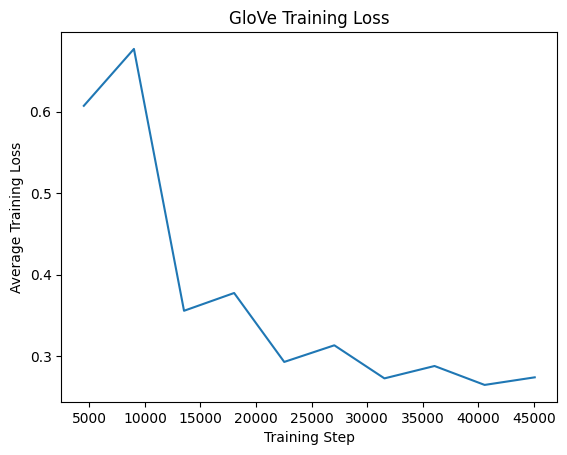

Training completed in 4.92 minutes


In [ ]:
start_time = time.time()

run_training(
    epochs = 10,
    lr=0.01,  # Learning rate
    checkpoint_model_path='./baseline_model_checkpoints',  # Directory to save model checkpoints
    final_model_path='./final_model',  # Directory to save the final model and embeddings
    vocab_size=int(1e5),  # Vocabulary size
    batch_size=512,  # Batch size for training
    embedding_size=128,  # Embedding size (vector dimension)
    window_size=3,  # Context window size for co-occurrence
    checkpoint_step=2000,  # Save checkpoints after every 1000 steps
)

end_time = time.time()
total_time = (end_time - start_time) / 60
print(f"Training completed in {total_time:.2f} minutes")

**[Reference]**: Training completed after 10 epochs - Final Average Loss: 0.2742

## Running Experiments with various hyper-parameters for Glove

Make sure you tune the following hyper parameters:
  - Learning Rate (Can vary from 0.1 to 10)
  - Window size (Can vary from 1 to 10)
  - Embedding Size (Can vary from 50 to 300)

For each hyperparameter setting, you will see a plot for each model trained. Please see below for possible values of each hyperparameter that you can experiment with:
  - lr - [0.1, 0.5, 0.05, 0.01, 1]
  - window_size - [3, 4, 5, 10]
  - embedding_size - [50, 100, 200, 300]

### Experiment 1

For the first experiment, set window_size = 3. Then, vary the learning rate through all three possible values and train different models for each hyperparameter setting. Use the plotted loss for each model to then select the best value of learning rate to be used going forward. Also make sure to assign appropriate names to the checkpoint_model_path and final_model_path arguments.

#### Hyperparameter Setting 1 for Experiment 1

Created path: exp_1_setting_1_glove/
Most common words (+UNK) [['UNK', 0], ('the', 62827), ('of', 36789), ('and', 25238), ('one', 24679)]
Sample data: [632, 3668, 12, 6, 173, 2, 4288, 47, 63, 150] ['anarchism', 'originated', 'as', 'a', 'term', 'of', 'abuse', 'first', 'used', 'against']
Generating co-occurrence matrix...
Building cooccurrence matrix: on line 0/1000000
Building cooccurrence matrix: on line 100000/1000000
Building cooccurrence matrix: on line 200000/1000000
Building cooccurrence matrix: on line 300000/1000000
Building cooccurrence matrix: on line 400000/1000000
Building cooccurrence matrix: on line 500000/1000000
Building cooccurrence matrix: on line 600000/1000000
Building cooccurrence matrix: on line 700000/1000000
Building cooccurrence matrix: on line 800000/1000000
Building cooccurrence matrix: on line 900000/1000000
Co-occurrence matrix generated.
Printing Validation Set Words
Word: world, ID: 66
Word: its, ID: 46
Word: has, ID: 41
Word: he, ID: 32
Word: war, ID: 75


Epoch 1/10: 100%|██████████| 4507/4507 [00:23<00:00, 191.97it/s, Batch Loss=2.04, Avg Loss=2.18]


Epoch 1 completed - Average Loss: 2.0912
Checkpoint saved at step 4507 to exp_1_setting_1_glove//glove_model_step_4507.pt
Printing closest words
world: ['fact', 'UNK', 'include', 'general', 'pythia', 'UNK', 'chief', 'UNK']
its: ['bourne', 'clayton', 'UNK', 'UNK', 'cape', 'kutha', 'dwellings', 'other']
has: ['elects', 'virginity', 'baryons', 'UNK', 'accents', 'UNK', 'UNK', 'their']
he: ['UNK', 'large', 'view', 'UNK', 'nec', 'never', 'UNK', 'superscript']
war: ['when', 'government', 'did', 'would', 'no', 'of', 'century', 'internet']
they: ['UNK', 'mathrmy', 'UNK', 'sedna', 'places', 'anagrams', 'dufferin', 'UNK']
the: ['obscuring', 'UNK', 'campaign', 'bourgeois', 'UNK', 'esthetic', 'UNK', 'alonzo']
all: ['habor', 'porch', 'UNK', 'silently', 'UNK', 'wizard', 'are', 'UNK']
most: ['used', 'popular', 'can', 'union', 'f', 'what', 'UNK', 'army']
would: ['war', 'main', 'no', 'of', 'strong', 'if', 'north', 'national']
two: ['death', 'u', 'prelude', 'draw', 'UNK', 'biblica', 'sinauer', 'could']
w

Epoch 2/10: 100%|██████████| 4507/4507 [00:23<00:00, 189.27it/s, Batch Loss=250, Avg Loss=100]


Epoch 2 completed - Average Loss: 58.7100
Checkpoint saved at step 9014 to exp_1_setting_1_glove//glove_model_step_9014.pt
Printing closest words
world: ['over', 'states', 'each', 'common', 'new', 'different', 'later', 'country']
its: ['UNK', 'oxidative', 'become', 'however', 'huascar', 'hoplites', 'UNK', 'preparing']
has: ['naboth', 'gm', 'these', 'countries', 'hemophiliacs', 'curricula', 'klm', 'same']
he: ['headland', 'UNK', 'halftime', 'josquin', 'crc', 'first', 'partment', 'UNK']
war: ['out', 'would', 'century', 'year', 'through', 'may', 'english', 'since']
they: ['shorts', 'people', 'against', 'anti', 'five', 'usonia', 'retroviral', 'hubert']
the: ['rer', 'UNK', 'scholastic', 'casibari', 'hess', 'bidirectionality', 'UNK', 'hillfoot']
all: ['reconciling', 'baoil', 'carcinoma', 'tenascin', 'aeneid', 'disseisin', 'linked', 'are']
most: ['been', 'states', 'who', 'valuation', 'now', 'nealbutrus', 'monty', 'UNK']
would: ['people', 'year', 'anti', 'right', 'war', 'found', 'where', 'god'

...

Epoch 8 completed - Average Loss: 88.3898
Checkpoint saved at step 36056 to exp_1_setting_1_glove//glove_model_step_36056.pt
Printing closest words
world: ['seven', 'union', 'plunderers', 'offensives', 'UNK', 'wove', 'philately', 'intra']
its: ['UNK', 'UNK', 'UNK', 'UNK', 'UNK', 'UNK', 'first', 'UNK']
has: ['six', 'sprint', 'UNK', 'UNK', 'UNK', 'ramifications', 'amoebozoa', 'UNK']
he: ['had', 'but', 'UNK', 'UNK', 'UNK', 'squandering', 'susitna', 'UNK']
war: ['UNK', 'UNK', 'UNK', 'longtime', 'liquefy', 'independance', 'detest', 'UNK']
they: ['organize', 'UNK', 'stalinist', 'distraught', 'business', 'UNK', 'brugsch', 'cesstion']
the: ['grandnephew', 'UNK', 'valentinians', 'producing', 'UNK', 'UNK', 'deinosuchus', 'accumulator']
all: ['used', 'meditative', 'tallapoosa', 'billionaire', 'UNK', 'UNK', 'karting', 'either']
most: ['orients', 'bransfield', 'UNK', 'goal', 'UNK', 'lettres', 'UNK', 'castra']
would: ['sociolinguistic', 'UNK', 'UNK', 'distinguishable', 'confessors', 'infraclass', 'f

Epoch 9/10: 100%|██████████| 4507/4507 [00:24<00:00, 187.22it/s, Batch Loss=608, Avg Loss=208]


Epoch 9 completed - Average Loss: 112.7560
Checkpoint saved at step 40563 to exp_1_setting_1_glove//glove_model_step_40563.pt
Printing closest words
world: ['seven', 'greats', 'UNK', 'phagos', 'denude', 'inherits', 'equates', 'norwich']
its: ['UNK', 'UNK', 'ogilvie', 'returning', 'umm', 'stargate', 'UNK', 'UNK']
has: ['samothrace', 'UNK', 'UNK', 'UNK', 'questr', 'UNK', 'UNK', 'locations']
he: ['but', 'vera', 'riley', 'UNK', 'sits', 'peer', 'stepanov', 'UNK']
war: ['inaction', 'UNK', 'UNK', 'UNK', 'UNK', 'theotokos', 'UNK', 'god']
they: ['UNK', 'grazing', 'UNK', 'aper', 'aeschylus', 'UNK', 'gains', 'acetylates']
the: ['UNK', 'sepsis', 'radegund', 'UNK', 'walid', 'UNK', 'segregation', 'collision']
all: ['UNK', 'urgent', 'UNK', 'anagyros', 'UNK', 'homogenity', 'filipino', 'inflexion']
most: ['UNK', 'UNK', 'UNK', 'UNK', 'ingelham', 'UNK', 'spilled', 'UNK']
would: ['being', 'united', 'them', 'bijective', 'antoine', 'UNK', 'only', 'UNK']
two: ['UNK', 'stunting', 'prynne', 'vhdl', 'UNK', 'ore

Epoch 10/10: 100%|██████████| 4507/4507 [00:23<00:00, 187.98it/s, Batch Loss=340, Avg Loss=160]


Epoch 10 completed - Average Loss: 91.7088
Checkpoint saved at step 45070 to exp_1_setting_1_glove//glove_model_step_45070.pt
Printing closest words
world: ['seven', 'videla', 'xn', 'tiresias', 'ramos', 'hayq', 'UNK', 'UNK']
its: ['corrupts', 'permanganate', 'UNK', 'UNK', 'UNK', 'UNK', 'narrowness', 'UNK']
has: ['UNK', 'antennae', 'averroes', 'richter', 'UNK', 'UNK', 'UNK', 'malebranche']
he: ['but', 'cummin', 'UNK', 'UNK', 'ambroid', 'UNK', 'embeded', 'gatsby']
war: ['would', 'about', 'any', 'cushite', 'indented', 'then', 'UNK', 'UNK']
they: ['abs', 'UNK', 'submissions', 'utero', 'UNK', 'six', 'UNK', 'adjusted']
the: ['sofia', 'scattered', 'colonizer', 'UNK', 'shibasaburo', 'lxiii', 'inert', 'UNK']
all: ['UNK', 'telephony', 'UNK', 'UNK', 'UNK', 'UNK', 'cafe', 'UNK']
most: ['curiously', 'catwalk', 'UNK', 'asynchronous', 'UNK', 'mitaka', 'resold', 'schumpeter']
would: ['war', 'clay', 'UNK', 'these', 'UNK', 'may', 'sativum', 'smiths']
two: ['saltation', 'UNK', 'precept', 'UNK', 'UNK', 'U

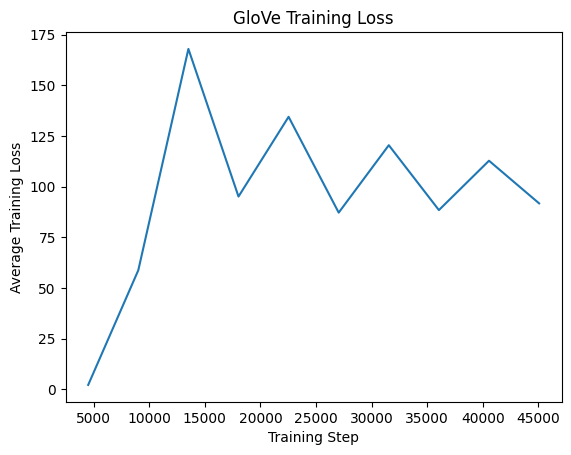

In [ ]:
# TODO(student): start

lr = 0.05 # Learning rate
checkpoint_model_path = "exp_1_setting_1"  # Path to save checkpoints
final_model_path = "exp_1_setting_1_final_model"  # Path to save the final model and embeddings

run_training(
    epochs = 10,
    lr=lr,  # Learning rate
    checkpoint_model_path=checkpoint_model_path,  # Directory to save model checkpoints
    final_model_path=final_model_path,  # Directory to save the final model and embeddings
    vocab_size=int(1e5),  # Vocabulary size
    batch_size=512,  # Batch size for training
    embedding_size=128,  # Embedding size (vector dimension)
    window_size=3,  # Context window size for co-occurrence
    checkpoint_step=5000  # Save checkpoints after every 1000 steps
)

# TODO(student): end


#### Hyperparameter Setting 2 for Experiment 1

Created path: exp_1_setting_2_glove/
Most common words (+UNK) [['UNK', 0], ('the', 62827), ('of', 36789), ('and', 25238), ('one', 24679)]
Sample data: [632, 3668, 12, 6, 173, 2, 4288, 47, 63, 150] ['anarchism', 'originated', 'as', 'a', 'term', 'of', 'abuse', 'first', 'used', 'against']
Generating co-occurrence matrix...
Building cooccurrence matrix: on line 0/1000000
Building cooccurrence matrix: on line 100000/1000000
Building cooccurrence matrix: on line 200000/1000000
Building cooccurrence matrix: on line 300000/1000000
Building cooccurrence matrix: on line 400000/1000000
Building cooccurrence matrix: on line 500000/1000000
Building cooccurrence matrix: on line 600000/1000000
Building cooccurrence matrix: on line 700000/1000000
Building cooccurrence matrix: on line 800000/1000000
Building cooccurrence matrix: on line 900000/1000000
Co-occurrence matrix generated.
Printing Validation Set Words
Word: only, ID: 74
Word: other, ID: 43
Word: see, ID: 71
Word: for, ID: 20
Word: had, ID: 4

Epoch 1/10: 100%|██████████| 4507/4507 [00:23<00:00, 188.68it/s, Batch Loss=12.3, Avg Loss=7.94]


Epoch 1 completed - Average Loss: 8.6502
Checkpoint saved at step 4507 to exp_1_setting_2_glove//glove_model_step_4507.pt
Printing closest words
only: ['convicted', 'south', 'UNK', 'auxiliary', 'betrothed', 'recruits', 'UNK', 'reading']
other: ['this', 'andurrial', 'james', 'galilean', 'cypherpunk', 'UNK', 'similarity', 'UNK']
see: ['barallete', 'secundus', 'bellingham', 'fesas', 'cavefish', 'deeps', 'semantics', 'anchorage']
for: ['flossing', 'japonic', 'three', 'derick', 'noor', 'vopo', 'appreciative', 'fancy']
had: ['but', 'be', 'basilica', 'fernbank', 'UNK', 'unflown', 'jiang', 'alger']
also: ['arsenal', 'carfree', 'bron', 'UNK', 'have', 'hologram', 'cutters', 'anthropology']
by: ['sobrero', 'mixtec', 'veerle', 'tarascan', 'redman', 'UNK', 'colonialism', 'domination']
that: ['tofana', 'the', 'referendum', 'second', 'aiwaz', 'chiba', 'he', 'UNK']
who: ['when', 'coves', 'arthrospira', 'lit', 'UNK', 'advent', 'UNK', 'recently']
states: ['organic', 'back', 'UNK', 'over', 'westhill', 't

Epoch 2/10: 100%|██████████| 4507/4507 [00:23<00:00, 189.70it/s, Batch Loss=2.79e+3, Avg Loss=1.22e+3]


Epoch 2 completed - Average Loss: 832.7566
Checkpoint saved at step 9014 to exp_1_setting_2_glove//glove_model_step_9014.pt
Printing closest words
only: ['well', 'UNK', 'world', 'UNK', 'up', 'we', 'vil', 'would']
other: ['there', 'new', 'UNK', 'robinia', 'english', 'UNK', 'greviously', 'easily']
see: ['UNK', 'UNK', 'grewingk', 'cel', 'naguals', 'kan', 'fries', 'UNK']
for: ['newington', 'dhul', 'tiebreak', 'responds', 'UNK', 'UNK', 'teetotalers', 'demyelination']
had: ['their', 'also', 'internetwork', 'ultraviolet', 'milankovi', 'UNK', 'shirts', 'UNK']
also: ['their', 'helped', 'had', 'hazardous', 'UNK', 'lofts', 'UNK', 'heracleum']
by: ['negative', 'cheops', 'laudation', 'upanishads', 'striving', 'semin', 'sch', 'torta']
that: ['abuses', 'missourians', 'girdle', 'preternatural', 'lent', 'reflexive', 'systemically', 'history']
who: ['sure', 'aegae', 'laurinaitis', 'UNK', 'cleaners', 'UNK', 'thug', 'turner']
states: ['often', 'like', 'said', 'do', 'world', 'them', 'word', 'century']
eigh

...

Epoch 8 completed - Average Loss: 1272.8285
Checkpoint saved at step 36056 to exp_1_setting_2_glove//glove_model_step_36056.pt
Printing closest words
only: ['pelican', 'UNK', 'proline', 'ebook', 'hoping', 'atra', 'interconversion', 'UNK']
other: ['liar', 'straits', 'zooxanthellae', 'exuere', 'ingeborg', 'klondike', 'fledge', 'UNK']
see: ['UNK', 'part', 'frigidarium', 'resonator', 'UNK', 'syllabics', 'UNK', 'quite']
for: ['drinkers', 'output', 'UNK', 'poullain', 'hurriedly', 'UNK', 'dionysos', 'unanimous']
had: ['sq', 'has', 'UNK', 'UNK', 'acacio', 'issue', 'scenes', 'lomonosov']
also: ['UNK', 'UNK', 'demigod', 'eedles', 'UNK', 'toleration', 'jennifer', 'UNK']
by: ['geoworks', 'UNK', 'UNK', 'hurteri', 'responds', 'tories', 'UNK', 'syllogisms']
that: ['UNK', 'portrayed', 'UNK', 'UNK', 'UNK', 'UNK', 'shepherd', 'UNK']
who: ['UNK', 'UNK', 'vauvenargues', 'fissures', 'sakuma', 'rainwater', 'hinders', 'compliant']
states: ['world', 'between', 'may', 'them', 'agrarianism', 'UNK', 'much', 'UNK

Epoch 9/10: 100%|██████████| 4507/4507 [00:23<00:00, 187.92it/s, Batch Loss=1.01e+4, Avg Loss=3.42e+3]


Epoch 9 completed - Average Loss: 1839.8145
Checkpoint saved at step 40563 to exp_1_setting_2_glove//glove_model_step_40563.pt
Printing closest words
only: ['UNK', 'UNK', 'UNK', 'UNK', 'UNK', 'UNK', 'UNK', 'UNK']
other: ['melts', 'UNK', 'representation', 'morphogenesis', 'adhocracies', 'UNK', 'not', 'UNK']
see: ['UNK', 'leaping', 'UNK', 'UNK', 'UNK', 'UNK', 'UNK', 'UNK']
for: ['UNK', 'precaution', 'mediate', 'levelled', 'UNK', 'UNK', 'UNK', 'shr']
had: ['landscaped', 'zaro', 'agattu', 'UNK', 'UNK', 'belissen', 'noblewomen', 'UNK']
also: ['hypothetical', 'hoover', 'UNK', 'UNK', 'tsarina', 'estimate', 'arsenopyrite', 'UNK']
by: ['UNK', 'UNK', 'legal', 'magnesia', 'directing', 'UNK', 'gayet', 'mvd']
that: ['altay', 'anarchoblogs', 'imply', 'inkas', 'UNK', 'lfa', 'iuventutis', 'UNK']
who: ['UNK', 'UNK', 'writes', 'stupa', 'iy', 'UNK', 'natur', 'resolutely']
states: ['UNK', 'tropics', 'UNK', 'electorates', 'UNK', 'UNK', 'UNK', 'morse']
eight: ['gravitation', 'pawns', 'UNK', 'UNK', 'UNK', 'c

Epoch 10/10: 100%|██████████| 4507/4507 [00:24<00:00, 187.36it/s, Batch Loss=6.3e+3, Avg Loss=2.28e+3]


Epoch 10 completed - Average Loss: 1344.1214
Checkpoint saved at step 45070 to exp_1_setting_2_glove//glove_model_step_45070.pt
Printing closest words
only: ['laboratories', 'will', 'these', 'zapotec', 'UNK', 'wara', 'iceland', 'explict']
other: ['protodynastic', 'affectional', 'UNK', 'inexorably', 'nedao', 'electrodynamic', 'UNK', 'looking']
see: ['actaeon', 'ups', 'UNK', 'emboldened', 'laptop', 'opposition', 'ethnological', 'ionianism']
for: ['UNK', 'novelists', 'UNK', 'UNK', 'UNK', 'april', 'goodrich', 'nazism']
had: ['excessive', 'theodefrid', 'heralds', 'UNK', 'stocks', 'UNK', 'kawm', 'verbally']
also: ['UNK', 'UNK', 'marseillaise', 'UNK', 'minimize', 'UNK', 'versified', 'be']
by: ['leftarrow', 'UNK', 'UNK', 'wrttn', 'UNK', 'UNK', 'mapusagafou', 'basketmaker']
that: ['bothering', 'UNK', 'pliocene', 'UNK', 'UNK', 'UNK', 'UNK', 'childish']
who: ['douala', 'UNK', 'UNK', 'gdansk', 'schemes', 'patchy', 'foremost', 'UNK']
states: ['war', 'however', 'world', 'UNK', 'UNK', 'now', 'UNK', '

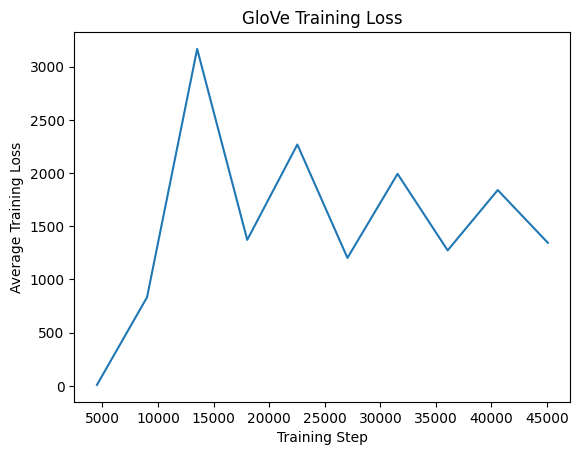

In [ ]:
# TODO(student): start

lr = 0.1 # Learning rate
checkpoint_model_path = "exp_1_setting_2" # Path to save checkpoints
final_model_path = "exp_1_setting_2_final_model" # Path to save the final model and embeddings

run_training(
    epochs = 10,
    lr=lr,  # Learning rate
    checkpoint_model_path=checkpoint_model_path,  # Directory to save model checkpoints
    final_model_path=final_model_path,  # Directory to save the final model and embeddings
    vocab_size=int(1e5),  # Vocabulary size
    batch_size=512,  # Batch size for training
    embedding_size=128,  # Embedding size (vector dimension)
    window_size=3,  # Context window size for co-occurrence
    checkpoint_step=5000  # Save checkpoints after every 1000 steps
)

# TODO(student): end


#### Hyperparameter Setting 3 for Experiment 1

Created path: exp_1_setting_3_glove/
Most common words (+UNK) [['UNK', 0], ('the', 62827), ('of', 36789), ('and', 25238), ('one', 24679)]
Sample data: [632, 3668, 12, 6, 173, 2, 4288, 47, 63, 150] ['anarchism', 'originated', 'as', 'a', 'term', 'of', 'abuse', 'first', 'used', 'against']
Generating co-occurrence matrix...
Building cooccurrence matrix: on line 0/1000000
Building cooccurrence matrix: on line 100000/1000000
Building cooccurrence matrix: on line 200000/1000000
Building cooccurrence matrix: on line 300000/1000000
Building cooccurrence matrix: on line 400000/1000000
Building cooccurrence matrix: on line 500000/1000000
Building cooccurrence matrix: on line 600000/1000000
Building cooccurrence matrix: on line 700000/1000000
Building cooccurrence matrix: on line 800000/1000000
Building cooccurrence matrix: on line 900000/1000000
Co-occurrence matrix generated.
Printing Validation Set Words
Word: them, ID: 96
Word: four, ID: 21
Word: it, ID: 30
Word: history, ID: 83
Word: years, I

Epoch 1/10: 100%|██████████| 4507/4507 [00:23<00:00, 190.89it/s, Batch Loss=180, Avg Loss=165]


Epoch 1 completed - Average Loss: 907.7487
Checkpoint saved at step 4507 to exp_1_setting_3_glove//glove_model_step_4507.pt
Printing closest words
them: ['met', 'easier', 'debates', 'lastly', 'hampers', 'guthrie', 'bringers', 'mouse']
four: ['grosjean', 'tamerlano', 'sebastien', 'bykovsky', 'blewski', 'beretta', 'amin', 'convent']
it: ['hurled', 'intentional', 'juxtaposition', 'rasav', 'chun', 'reevaulation', 'surely', 'dilemmas']
history: ['executing', 'british', 'production', 'sensual', 'nicotinic', 'acetaminophenol', 'fragile', 'avshalom']
years: ['wales', 'wishes', 'review', 'state', 'pinnacle', 'walls', 'nicotinic', 'set']
its: ['fillm', 'faith', 'government', 'bandage', 'trummet', 'poised', 'robby', 'epiph']
states: ['symbiotic', 'radar', 'despite', 'legalized', 'UNK', 'altruists', 'waves', 'michael']
people: ['damned', 'ayo', 'grabs', 'unawatuna', 'larson', 'stimming', 'salat', 'housman']
no: ['dismissing', 'may', 'force', 'taper', 'imsa', 'muttered', 'cassius', 'flourish']
or: 

Epoch 2/10: 100%|██████████| 4507/4507 [00:23<00:00, 187.90it/s, Batch Loss=6.55e+5, Avg Loss=5.37e+5]


Epoch 2 completed - Average Loss: 413914.3055
Checkpoint saved at step 9014 to exp_1_setting_3_glove//glove_model_step_9014.pt
Printing closest words
them: ['through', 'during', 'physical', 'down', 'alexander', 'player', 'german', 'will']
four: ['eccentric', 'rhinoceroses', 'helots', 'vartan', 'donate', 'edukators', 'digeridoo', 'ascorbic']
it: ['succinifera', 'excuse', 'wenthal', 'develop', 'house', 'moralistic', 'UNK', 'philological']
history: ['i', 'films', 'non', 'includes', 'its', 'free', 'references', 'made']
years: ['national', 'philosophy', 'between', 'set', 'state', 'e', 'without', 'absolute']
its: ['her', 'history', 'not', 'fortunate', 'known', 'jews', 'they', 'version']
states: ['life', 'city', 'b', 'those', 'film', 'although', 'people', 'following']
people: ['because', 'film', 'first', 'although', 'states', 'words', 'good', 'she']
no: ['world', 'south', 'day', 'UNK', 'come', 'up', 'their', 'century']
or: ['nontheism', 'UNK', 'perisapora', 'crafoord', 'haloalkane', 'mefferdi

...

Epoch 8 completed - Average Loss: 735228.0957
Checkpoint saved at step 36056 to exp_1_setting_3_glove//glove_model_step_36056.pt
Printing closest words
them: ['UNK', 'alludes', 'since', 'UNK', 'counting', 'UNK', 'UNK', 'capcoms']
four: ['credo', 'UNK', 'UNK', 'UNK', 'giese', 'machining', 'asher', 'dissent']
it: ['UNK', 'fashions', 'UNK', 'UNK', 'scrutinised', 'western', 'UNK', 'UNK']
history: ['transfinite', 'UNK', 'diaries', 'UNK', 'transaction', 'gaia', 'dumasia', 'simplicity']
years: ['proviso', 'kingssonar', 'wr', 'demarcation', 'gestis', 'UNK', 'amali', 'UNK']
its: ['UNK', 'dismissing', 'such', 'subdititos', 'muster', 'bewildering', 'kalbbia', 'UNK']
states: ['world', 'UNK', 'UNK', 'UNK', 'bokuto', 'UNK', 'UNK', 'UNK']
people: ['hieroglyph', 'confederal', 'capitalised', 'war', 'what', 'known', 'scilly', 'hallowed']
no: ['kushi', 'UNK', 'drupe', 'smyrnaeus', 'nearchus', 'bonito', 'UNK', 'heracles']
or: ['UNK', 'energetic', 'UNK', 'occultists', 'grizzard', 'pentanol', 'entropyandtem

Epoch 9/10: 100%|██████████| 4507/4507 [00:23<00:00, 189.12it/s, Batch Loss=5.9e+6, Avg Loss=1.95e+6]


Epoch 9 completed - Average Loss: 1063249.1910
Checkpoint saved at step 40563 to exp_1_setting_3_glove//glove_model_step_40563.pt
Printing closest words
them: ['survivor', 'UNK', 'tradewinds', 'concubines', 'UNK', 'innuendo', 'franck', 'dashing']
four: ['sozomen', 'millimetres', 'everitt', 'UNK', 'squat', 'obstruction', 'outta', 'UNK']
it: ['portmanteau', 'UNK', 'flexispina', 'UNK', 'nc', 'observances', 'UNK', 'monomanical']
history: ['century', 'out', 'film', 'same', 'vedrosha', 'did', 'day', 'year']
years: ['century', 'book', 'UNK', 'hout', 'UNK', 'beatified', 'dan', 'UNK']
its: ['proslavery', 'faculties', 'UNK', 'mendel', 'UNK', 'ner', 'UNK', 'UNK']
states: ['careers', 'UNK', 'UNK', 'recoverable', 'korbinian', 'known', 'UNK', 'however']
people: ['UNK', 'throat', 'UNK', 'UNK', 'UNK', 'sweeteners', 'UNK', 'rocketry']
no: ['UNK', 'UNK', 'sadalmelik', 'anubis', 'UNK', 'iiia', 'UNK', 'UNK']
or: ['mitra', 'lens', 'tkabir', 'UNK', 'column', 'UNK', 'togarmah', 'inflict']
these: ['UNK', 'UNK

Epoch 10/10: 100%|██████████| 4507/4507 [00:23<00:00, 188.30it/s, Batch Loss=3.74e+6, Avg Loss=1.35e+6]


Epoch 10 completed - Average Loss: 801748.5250
Checkpoint saved at step 45070 to exp_1_setting_3_glove//glove_model_step_45070.pt
Printing closest words
them: ['kuwaiti', 'UNK', 'tantra', 'UNK', 'coelom', 'shaoyin', 'apology', 'bletchley']
four: ['credo', 'penrose', 'was', 'pirze', 'updates', 'pawns', 'UNK', 'cma']
it: ['UNK', 'UNK', 'jiggled', 'helmut', 'UNK', 'hecuba', 'altruistic', 'trakl']
history: ['UNK', 'UNK', 'seyss', 'caudatus', 'marred', 'sergeant', 'UNK', 'cyprus']
years: ['then', 'yourdon', 'UNK', 'tenor', 'tiled', 'offset', 'nicklaus', 'dositheus']
its: ['muster', 'tereshkova', 'UNK', 'UNK', 'drumheller', 'elapidae', 'exchristian', 'UNK']
states: ['UNK', 'time', 'UNK', 'habitable', 'unilateralis', 'camarasaurus', 'UNK', 'UNK']
people: ['lorne', 'fitzjames', 'macleod', 'UNK', 'UNK', 'UNK', 'UNK', 'UNK']
no: ['UNK', 'UNK', 'UNK', 'UNK', 'carborundum', 'UNK', 'sentimentality', 'UNK']
or: ['UNK', 'UNK', 'meal', 'UNK', 'epub', 'zermelo', 'UNK', 'khene']
these: ['bourg', 'hundre

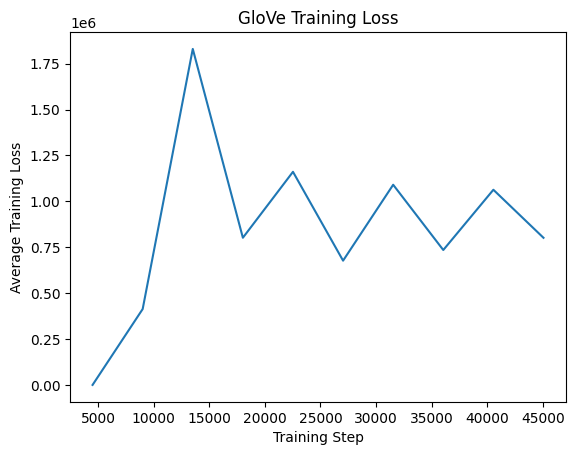

In [ ]:
# TODO(student): start

lr = 0.5
checkpoint_model_path = "exp_1_setting_3"
final_model_path = "exp_1_setting_3_final_model"

run_training(
    epochs = 10,
    lr=lr,  # Learning rate
    checkpoint_model_path=checkpoint_model_path,  # Directory to save model checkpoints
    final_model_path=final_model_path,  # Directory to save the final model and embeddings
    vocab_size=int(1e5),  # Vocabulary size
    batch_size=512,  # Batch size for training
    embedding_size=128,  # Embedding size (vector dimension)
    window_size=3,  # Context window size for co-occurrence
    checkpoint_step=5000  # Save checkpoints after every 1000 steps
)

# TODO(student): end


<b> What is the best learning rate for GloVe model and why? What did you learn from the plots? </b>

TODO(students): start

Best learning rate for above Glove model is 0.01. From above experiments, as learning rate increases, the avg loss for the whole experiment is going to increase a lot. So, learning rate should be as less as possible and also not too small. I think 0.01 is good enough to train the glove model.

Learning from Plots:
1. Avg loss increases initially. And then decreases to a saturation point in each epoch.
2. as learning rate increases from 0.01, the avg loss of model increases drastically.
3. for lr=0.01, loss is in order of 0.1
4. for lr=0.05, loss is in order of 10^2 (drastical increase)
5. for lr=0.1, loss is in order of 10^6.

TODO(students): end

In [ ]:
## TODO(students): start

best_lr = 0.01

## TODO(students): end

### Experiment 2

Now, going forward, set the value of the learning rate to the best lr for that model type. For the second experiment, we will focus on varying the window size while keeping other parameters like the learning rate, embedding size, and batch size constant. The window size controls how many words before and after the target word are considered when building the co-occurrence matrix. This can have a significant effect on the quality of the learned embeddings.

#### Hyperparameter Setting 1 for Experiment 2

Created path: exp_2_setting_1_glove/
Most common words (+UNK) [['UNK', 0], ('the', 62827), ('of', 36789), ('and', 25238), ('one', 24679)]
Sample data: [632, 3668, 12, 6, 173, 2, 4288, 47, 63, 150] ['anarchism', 'originated', 'as', 'a', 'term', 'of', 'abuse', 'first', 'used', 'against']
Generating co-occurrence matrix...
Building cooccurrence matrix: on line 0/1000000
Building cooccurrence matrix: on line 100000/1000000
Building cooccurrence matrix: on line 200000/1000000
Building cooccurrence matrix: on line 300000/1000000
Building cooccurrence matrix: on line 400000/1000000
Building cooccurrence matrix: on line 500000/1000000
Building cooccurrence matrix: on line 600000/1000000
Building cooccurrence matrix: on line 700000/1000000
Building cooccurrence matrix: on line 800000/1000000
Building cooccurrence matrix: on line 900000/1000000
Co-occurrence matrix generated.
Printing Validation Set Words
Word: new, ID: 68
Word: were, ID: 42
Word: that, ID: 19
Word: called, ID: 89
Word: b, ID: 5

Epoch 1/10: 100%|██████████| 3116/3116 [00:16<00:00, 191.19it/s, Batch Loss=0.268, Avg Loss=0.432]


Epoch 1 completed - Average Loss: 0.7658
Checkpoint saved at step 3116 to exp_2_setting_1_glove//glove_model_step_3116.pt
Printing closest words
new: ['near', 'bourses', 'of', 'UNK', 'UNK', 'UNK', 'UNK', 'UNK']
were: ['UNK', 'milne', 'UNK', 'incoming', 'llamas', 'which', 'bam', 'UNK']
that: ['UNK', 'UNK', 'UNK', 'main', 'anniversary', 'orb', 'united', 'UNK']
called: ['UNK', 'rustica', 'UNK', 'UNK', 'UNK', 'amory', 'UNK', 'UNK']
b: ['UNK', 'afield', 'UNK', 'UNK', 'UNK', 'mkb', 'diamonds', 'nine']
which: ['predated', 'black', 'terms', 'UNK', 'UNK', 'hinged', 'UNK', 'ubiquitous']
some: ['UNK', 'trained', 'at', 'parliamentarian', 'aeroplanes', 'UNK', 'UNK', 'quotes']
these: ['programming', 'behaviors', 'barbadensis', 'UNK', 'dachau', 'emerging', 'alfrun', 'ned']
from: ['UNK', 'UNK', 's', 'yeshiva', 'UNK', 'UNK', 'cia', 'UNK']
they: ['UNK', 'o', 'themselves', 'doujinshi', 'inspectors', 'UNK', 'UNK', 'afyon']
not: ['splendor', 'UNK', 'thorough', 'UNK', 'aasim', 'naylan', 'UNK', 'record']
had

Epoch 2/10: 100%|██████████| 3116/3116 [00:16<00:00, 189.01it/s, Batch Loss=3.6, Avg Loss=1.22]


Epoch 2 completed - Average Loss: 0.9037
Checkpoint saved at step 6232 to exp_2_setting_1_glove//glove_model_step_6232.pt
Printing closest words
new: ['on', 'own', 'her', 'UNK', 'where', 'national', 'beijing', 'into']
were: ['this', 'which', 'its', 'had', 'where', 'some', 'on', 'to']
that: ['for', 'which', 'its', 'this', 'it', 'at', 'above', 'not']
called: ['gis', 'known', 'made', 'where', 'way', 'glotz', 'ft', 'webobjects']
b: ['which', 'originally', 'UNK', 'residual', 'although', 'against', 'lanes', 'it']
which: ['this', 'its', 'for', 'also', 'where', 'were', 'had', 'it']
some: ['its', 'were', 'after', 'this', 'into', 'to', 'which', 'it']
these: ['such', 'less', 'UNK', 'submachine', 'given', 'children', 'play', 'shimura']
from: ['were', 'had', 'its', 'of', 'by', 'this', 'which', 'for']
they: ['into', 'this', 'made', 'which', 'where', 'own', 'for', 'philosophy']
not: ['after', 'also', 'this', 'were', 'which', 'it', 'most', 'being']
had: ['which', 'were', 'its', 'for', 'this', 'where',

...

Epoch 8 completed - Average Loss: 0.2915
Checkpoint saved at step 24928 to exp_2_setting_1_glove//glove_model_step_24928.pt
Printing closest words
new: ['people', 'following', 'since', 'when', 'UNK', 'no', 'times', 'film']
were: ['most', 'while', 'some', 'first', 'he', 'four', 'last', 'where']
that: ['is', 'strenuous', 'appointed', 'your', 'borrowings', 'was', 'reduced', 'for']
called: ['malted', 'UNK', 'UNK', 'wird', 'UNK', 'turque', 'available', 'friendship']
b: ['late', 'f', 'actor', 'algol', 'i', 'around', 'england', 'august']
which: ['he', 'due', 'UNK', 'UNK', 'UNK', 'cafes', 'UNK', 'podcasting']
some: ['first', 'all', 'he', 'last', 'would', 'were', 'most', 'where']
these: ['overruled', 'node', 'perpetuated', 'prooem', 'UNK', 'UNK', 'UNK', 'bolax']
from: ['meritocracy', 'UNK', 'translucency', 'castellanos', 'UNK', 'dnipropetrovsk', 'excluded', 'organisation']
they: ['not', 'but', 'after', 'been', 'had', 'being', 'there', 'used']
not: ['they', 'but', 'been', 'used', 'could', 'them'

Epoch 9/10: 100%|██████████| 3116/3116 [00:16<00:00, 187.89it/s, Batch Loss=1.05, Avg Loss=0.345]


Epoch 9 completed - Average Loss: 0.2820
Checkpoint saved at step 28044 to exp_2_setting_1_glove//glove_model_step_28044.pt
Printing closest words
new: ['work', 'city', 'metaphorical', 'kinetic', 'under', 'hearts', 'UNK', 'chapin']
were: ['have', 'also', 'all', 'be', 'when', 'often', 'called', 'see']
that: ['for', 'six', 'nine', 'zero', 'has', 'in', 'around', 'not']
called: ['when', 'all', 'have', 'if', 'based', 'now', 'be', 'had']
b: ['both', 'own', 'great', 'its', 'world', 'so', 'old', 'can']
which: ['it', 'be', 'are', 'even', 'year', 'no', 'UNK', 'at']
some: ['screenwriting', 'sieberiana', 'yoshokai', 'small', 'UNK', 'UNK', 'mayor', 'UNK']
these: ['when', 'no', 'where', 'even', 'see', 'at', 'who', 'all']
from: ['were', 'have', 'the', 'eight', 'other', 'be', 'in', 'an']
they: ['b', 'include', 'both', 'old', 'been', 'own', 'england', 'world']
not: ['a', 'eight', 'other', 'had', 'his', 'who', 'the', 'at']
had: ['other', 'than', 'have', 'time', 'their', 'to', 'what', 'called']
at: ['are

Epoch 10/10: 100%|██████████| 3116/3116 [00:16<00:00, 189.19it/s, Batch Loss=1.01, Avg Loss=0.331]


Epoch 10 completed - Average Loss: 0.2689
Checkpoint saved at step 31160 to exp_2_setting_1_glove//glove_model_step_31160.pt
Printing closest words
new: ['state', 'time', 'being', 'general', 'people', 'east', 'west', 'while']
were: ['be', 'he', 'some', 'all', 'when', 'first', 'while', 'because']
that: ['domicile', 'seinfeld', 'UNK', 'nonprofit', 'khar', 'UNK', 'baird', 'nightfall']
called: ['known', 'some', 'while', 'because', 'were', 'been', 'himself', 'over']
b: ['actor', 'years', 'only', 'apollo', 'states', 'french', 'm', 'u']
which: ['or', 'he', 'be', 'first', 'this', 'but', 'people', 'with']
some: ['first', 'can', 'only', 'when', 'been', 'him', 'all', 'he']
these: ['ignatians', 'volcanos', 'UNK', 'UNK', 'dirac', 'tanha', 'diol', 'in']
from: ['menem', 'ostensible', 'equations', 'somnum', 'ravenna', 'somali', 'their', 'inflorescence']
they: ['may', 'some', 'only', 'can', 'him', 'but', 'while', 'no']
not: ['are', 'UNK', 'UNK', 'it', 'suspending', 'nighthorse', 'tonio', 'pulitzer']
ha

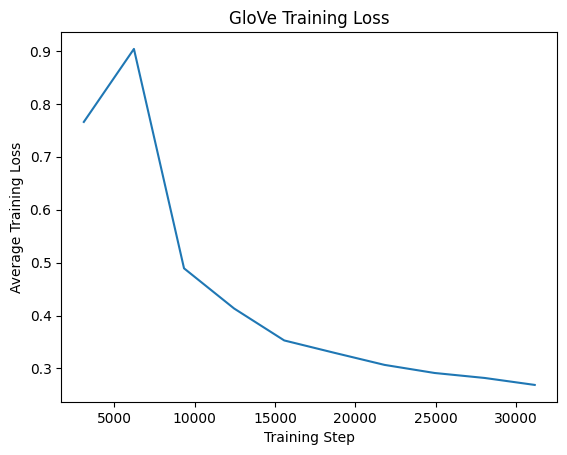

In [ ]:
# TODO(student): start

lr = best_lr  # Learning rate (fixed) - from experiment 1
checkpoint_model_path = "exp_2_setting_1" # Path to save checkpoints
final_model_path = "exp_2_setting_1_final_model" # Path to save the final model and embeddings

# Experiment 2: Vary the window size
# You can run this with different window sizes (e.g., 2, 3, 5, 10)
window_size = 2

run_training(
    epochs=10,  # Number of epochs to train
    lr=lr,  # Learning rate
    checkpoint_model_path=checkpoint_model_path,  # Directory to save model checkpoints
    final_model_path=final_model_path,  # Directory to save the final model and embeddings
    vocab_size=int(1e5),  # Vocabulary size
    batch_size=512,  # Batch size for training
    embedding_size=128,  # Embedding size (vector dimension)
    window_size=window_size,  # Context window size for co-occurrence
    checkpoint_step=5000,  # Save checkpoints after every 2000 steps
)

# TODO(student): end


#### Hyperparameter Setting 2 for Experiment 2

Created path: exp_2_setting_2_glove/
Most common words (+UNK) [['UNK', 0], ('the', 62827), ('of', 36789), ('and', 25238), ('one', 24679)]
Sample data: [632, 3668, 12, 6, 173, 2, 4288, 47, 63, 150] ['anarchism', 'originated', 'as', 'a', 'term', 'of', 'abuse', 'first', 'used', 'against']
Generating co-occurrence matrix...
Building cooccurrence matrix: on line 0/1000000
Building cooccurrence matrix: on line 100000/1000000
Building cooccurrence matrix: on line 200000/1000000
Building cooccurrence matrix: on line 300000/1000000
Building cooccurrence matrix: on line 400000/1000000
Building cooccurrence matrix: on line 500000/1000000
Building cooccurrence matrix: on line 600000/1000000
Building cooccurrence matrix: on line 700000/1000000
Building cooccurrence matrix: on line 800000/1000000
Building cooccurrence matrix: on line 900000/1000000
Co-occurrence matrix generated.
Printing Validation Set Words
Word: see, ID: 71
Word: this, ID: 36
Word: states, ID: 76
Word: these, ID: 65
Word: he, ID:

Epoch 1/10: 100%|██████████| 6900/6900 [00:36<00:00, 191.18it/s, Batch Loss=0.132, Avg Loss=0.188]


Epoch 1 completed - Average Loss: 0.4807
Checkpoint saved at step 6900 to exp_2_setting_2_glove//glove_model_step_6900.pt
Printing closest words
see: ['has', 'during', 'j', 'game', 'their', 'UNK', 'UNK', 'thrombocyte']
this: ['including', 'adding', 'are', 'who', 'issues', 'its', 'group', 'united']
states: ['duby', 'UNK', 'UNK', 'UNK', 'UNK', 'UNK', 'UNK', 'gwyneth']
these: ['people', 'e', 'february', 'him', 'under', 'early', 'are', 'been']
he: ['an', 'then', 'it', 'when', 'as', 'UNK', 'that', 'and']
used: ['but', 'friedrich', 'UNK', 'internship', 'death', 'UNK', 'wafl', 'while']
the: ['and', 'UNK', 'an', 'UNK', 'michelle', 'UNK', 'adjoins', 'died']
two: ['UNK', 'UNK', 'faoi', 'coherent', 'UNK', 'kemmler', 'UNK', 'UNK']
people: ['these', 'ildico', 'containing', 'UNK', 'UNK', 'anthracene', 'UNK', 'UNK']
eight: ['was', 'vipsania', 'musician', 'UNK', 'UNK', 'UNK', 'ak', 'nine']
other: ['although', 'what', 'against', 'vali', 'until', 'day', 'most', 'UNK']
on: ['an', 'his', 's', 'world', 'as

Epoch 2/10: 100%|██████████| 6900/6900 [00:36<00:00, 189.19it/s, Batch Loss=1.41, Avg Loss=0.95]


Epoch 2 completed - Average Loss: 0.4779
Checkpoint saved at step 13800 to exp_2_setting_2_glove//glove_model_step_13800.pt
Printing closest words
see: ['name', 'major', 'national', 'd', 'most', 'took', 'become', 'an']
this: ['between', 'out', 'united', 'including', 'same', 'book', 'last', 'economic']
states: ['many', 'under', 'use', 'time', 'more', 'about', 'country', 'day']
these: ['received', 'alkanes', 'another', 'completely', 'sender', 'activate', 'releasing', 'UNK']
he: ['that', 'UNK', 'no', 'compactification', 'has', 'UNK', 'stock', 'incarnation']
used: ['major', 'national', 'should', 'instead', 'never', 'held', 'name', 'using']
the: ['generally', 'only', 'when', 'UNK', 'many', 'union', 'australian', 'UNK']
two: ['UNK', 'UNK', 'seven', 'lito', 'UNK', 'UNK', 'UNK', 'UNK']
people: ['only', 'under', 'known', 'states', 'more', 'new', 'through', 'time']
eight: ['six', 'after', 'under', 'only', 'would', 'general', 'were', 'about']
other: ['but', 'are', 'into', 'well', 'until', 'most',

...

Epoch 8 completed - Average Loss: 0.2565
Checkpoint saved at step 55200 to exp_2_setting_2_glove//glove_model_step_55200.pt
Printing closest words
see: ['or', 'time', 'were', 'than', 'her', 'at', 'its', 'has']
this: ['on', 'some', 'dagny', 'lifts', 'pyrotechnic', 'superscript', 'mercy', 'UNK']
states: ['being', 'new', 'example', 'long', 'theory', 'united', 'usually', 'france']
these: ['against', 'most', 'still', 'them', 'austria', 'their', 'only', 'major']
he: ['or', 'have', 'his', 'it', 'are', 'see', 'at', 'to']
used: ['use', 'name', 'been', 'time', 'known', 'more', 'her', 'until']
the: ['one', 'to', 'is', 'as', 'zero', 'of', 'in', 'or']
two: ['was', 'lapis', 'by', 'eight', 'on', 'conscriptum', 'volume', 'eixample']
people: ['like', 'apollo', 'even', 'both', 'life', 'city', 'found', 'itself']
eight: ['opioids', 'mammalia', 'on', 'two', 'UNK', 'capita', 'UNK', 'flip']
other: ['but', 'were', 'her', 'when', 'man', 'more', 'thus', 'until']
on: ['was', 'this', 'four', 'some', 'eight', 'mir

Epoch 9/10: 100%|██████████| 6900/6900 [00:36<00:00, 187.97it/s, Batch Loss=0.572, Avg Loss=0.443]


Epoch 9 completed - Average Loss: 0.2303
Checkpoint saved at step 62100 to exp_2_setting_2_glove//glove_model_step_62100.pt
Printing closest words
see: ['seven', 'five', 'ural', 'his', 'are', 'hh', 'mississippian', 'gregor']
this: ['that', 'an', 'by', 'be', 'nine', 'with', 'than', 'was']
states: ['new', 'being', 'more', 'between', 'can', 'may', 'various', 'theory']
these: ['no', 'only', 'all', 'would', 'well', 'often', 'people', 'first']
he: ['took', 'it', 'at', 'under', 'is', 'given', 'used', 'state']
used: ['more', 'who', 'known', 'can', 'use', 'name', 'may', 'all']
the: ['and', 'of', 'nine', 'two', 'a', 'that', 'was', 'be']
two: ['eight', 'four', 'nine', 'three', 'was', 'and', 'that', 'the']
people: ['even', 'city', 'war', 'them', 'no', 'first', 'only', 'state']
eight: ['two', 'four', 'three', 'was', 'nine', 'that', 'by', 'with']
other: ['UNK', 'allemanni', 'UNK', 'UNK', 'were', 'farhud', 'UNK', 'UNK']
on: ['cactus', 'meran', 'anatomy', 'UNK', 'anacondas', 'gastrula', 'nubia', 'UNK'

Epoch 10/10: 100%|██████████| 6900/6900 [00:37<00:00, 186.48it/s, Batch Loss=0.799, Avg Loss=0.513]


Epoch 10 completed - Average Loss: 0.2484
Checkpoint saved at step 69000 to exp_2_setting_2_glove//glove_model_step_69000.pt
Printing closest words
see: ['over', 'between', 'i', 'people', 'god', 'history', 'used', 'natural']
this: ['for', 'as', 'is', 'are', 'five', 'some', 'but', 'it']
states: ['being', 'there', 'year', 'then', 'some', 'left', 'after', 'often']
these: ['after', 'then', 'some', 'new', 'been', 'b', 'law', 'both']
he: ['it', 'this', 'then', 'very', 'some', 's', 'states', 'same']
used: ['can', 'i', 'name', 'over', 'between', 'people', 'possible', 'known']
the: ['one', 'to', 'zero', 'is', 'for', 'this', 'not', 'number']
two: ['that', 'which', 'four', 'six', 'more', 'nine', 'all', 'missions']
people: ['even', 'between', 'name', 'until', 'over', 'battle', 'list', 'historical']
eight: ['s', 'UNK', 'so', 'very', 'in', 'four', 'be', 'lincoln']
other: ['part', 'lies', 'UNK', 'starhawk', 'battista', 'UNK', 'UNK', 'bibel']
on: ['is', 's', 'as', 'in', 'to', 'zero', 'five', 'number']

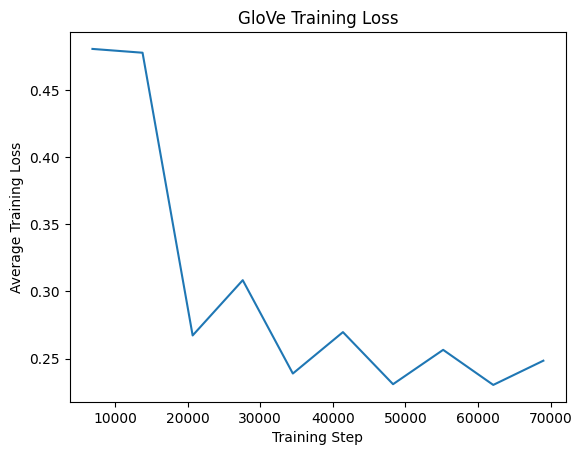

In [ ]:
# TODO(student): start

lr = best_lr  # Learning rate (fixed) - from experiment 1
checkpoint_model_path = "exp_2_setting_2" # Path to save checkpoints
final_model_path = "exp_2_setting_2_final_model" # Path to save the final model and embeddings

# Experiment 2: Vary the window size
# You can run this with different window sizes (e.g., 2, 3, 5, 10)
window_size = 5

run_training(
    epochs=10,  # Number of epochs to train
    lr=lr,  # Learning rate
    checkpoint_model_path=checkpoint_model_path,  # Directory to save model checkpoints
    final_model_path=final_model_path,  # Directory to save the final model and embeddings
    vocab_size=int(1e5),  # Vocabulary size
    batch_size=512,  # Batch size for training
    embedding_size=128,  # Embedding size (vector dimension)
    window_size=window_size,  # Context window size for co-occurrence
    checkpoint_step=5000,  # Save checkpoints after every 2000 steps
)

# TODO(student): end


#### Hyperparameter Setting 3 for Experiment 2

Created path: exp_2_setting_3_glove/
Most common words (+UNK) [['UNK', 0], ('the', 62827), ('of', 36789), ('and', 25238), ('one', 24679)]
Sample data: [632, 3668, 12, 6, 173, 2, 4288, 47, 63, 150] ['anarchism', 'originated', 'as', 'a', 'term', 'of', 'abuse', 'first', 'used', 'against']
Generating co-occurrence matrix...
Building cooccurrence matrix: on line 0/1000000
Building cooccurrence matrix: on line 100000/1000000
Building cooccurrence matrix: on line 200000/1000000
Building cooccurrence matrix: on line 300000/1000000
Building cooccurrence matrix: on line 400000/1000000
Building cooccurrence matrix: on line 500000/1000000
Building cooccurrence matrix: on line 600000/1000000
Building cooccurrence matrix: on line 700000/1000000
Building cooccurrence matrix: on line 800000/1000000
Building cooccurrence matrix: on line 900000/1000000
Co-occurrence matrix generated.
Printing Validation Set Words
Word: has, ID: 41
Word: this, ID: 36
Word: some, ID: 50
Word: so, ID: 93
Word: these, ID: 6

Epoch 1/10: 100%|██████████| 11804/11804 [01:02<00:00, 189.50it/s, Batch Loss=0.237, Avg Loss=0.153]


Epoch 1 completed - Average Loss: 0.3408
Checkpoint saved at step 11804 to exp_2_setting_3_glove//glove_model_step_11804.pt
Printing closest words
has: ['UNK', 'UNK', 'anatolian', 'jews', 'omniglot', 'five', 'with', 'UNK']
this: ['just', 'an', 'all', 'itself', 'those', 'make', 'two', 'mesozoic']
some: ['will', 'such', 'system', 'UNK', 'its', 'UNK', 'including', 'hamedan']
so: ['terrail', 'quo', 'UNK', 'UNK', 'herrion', 'occuring', 'UNK', 'podio']
these: ['UNK', 'UNK', 'will', 'first', 'UNK', 'early', 'time', 'bayan']
war: ['ladar', 'solingen', 'israel', 'firebat', 'vol', 'fire', 'loc', 'UNK']
which: ['from', 'he', 'called', 'in', 'social', 'north', 'american', 'large']
they: ['but', 'defend', 'UNK', 'with', 'five', 'shrew', 'oldman', 'decompression']
have: ['at', 'called', 'he', 'that', 'because', 'be', 't', 'b']
all: ['an', 'this', 'but', 'more', 'i', 'her', 'those', 'power']
american: ['was', 'system', 'which', 'six', 'just', 'national', 'most', 'four']
no: ['same', 'her', 'UNK', 'UN

Epoch 2/10: 100%|██████████| 11804/11804 [01:02<00:00, 188.97it/s, Batch Loss=1.04, Avg Loss=0.634]


Epoch 2 completed - Average Loss: 0.3026
Checkpoint saved at step 23608 to exp_2_setting_3_glove//glove_model_step_23608.pt
Printing closest words
has: ['its', 'also', 'had', 's', 'been', 'after', 'it', 'united']
this: ['but', 'some', 'it', 'on', 'also', 'any', 'been', 'other']
some: ['but', 'other', 'any', 'this', 'world', 'on', 'life', 'must']
so: ['while', 'use', 'well', 'under', 'about', 'however', 'being', 'out']
these: ['who', 'be', 'god', 'more', 'made', 'that', 'either', 'created']
war: ['use', 'known', 'under', 'during', 'about', 'while', 'may', 'between']
which: ['from', 'a', 'was', 'most', 'how', 'builder', 'warrant', 'dentine']
they: ['their', 'for', 'or', 'by', 's', 'would', 'government', 'based']
have: ['applause', 'porus', 'UNK', 'UNK', 'kampf', 'UNK', 'gustavus', 'swayed']
all: ['called', 'there', 'using', 'took', 'd', 'because', 'british', 'state']
american: ['there', 'called', 'british', 'practice', 'd', 'all', 'force', 'first']
no: ['both', 'about', 'between', 'time'

...

Epoch 8 completed - Average Loss: 0.1931
Checkpoint saved at step 94432 to exp_2_setting_3_glove//glove_model_step_94432.pt
Printing closest words
has: ['also', 'only', 'united', 'that', 'he', 'had', 'where', 'people']
this: ['many', 'into', 'b', 'd', 'however', 'other', 'time', 'such']
some: ['victory', 'that', 'he', 'from', 'not', 'by', 'the', 'also']
so: ['later', 'these', 'number', 'part', 'their', 'death', 'produced', 'made']
these: ['their', 'would', 'been', 'three', 'its', 'but', 'will', 'not']
war: ['new', 'years', 'century', 'e', 'life', 'same', 'can', 'had']
which: ['six', 'between', 'known', 'other', 'UNK', 'they', 'such', 'with']
they: ['other', 'many', 'into', 'such', 'name', 'this', 'than', 'through']
have: ['that', 'had', 'he', 'even', 'it', 'by', 'not', 'be']
all: ['jewish', 'the', 'those', 'held', 'people', 'UNK', 'out', 'symbols']
american: ['b', 'd', 'this', 'like', 'particularly', 'al', 'means', 'alexander']
no: ['will', 'been', 'often', 'use', 'these', 'not', 'on',

Epoch 9/10: 100%|██████████| 11804/11804 [01:03<00:00, 186.22it/s, Batch Loss=0.566, Avg Loss=0.437]


Epoch 9 completed - Average Loss: 0.1829
Checkpoint saved at step 106236 to exp_2_setting_3_glove//glove_model_step_106236.pt
Printing closest words
has: ['have', 'only', 'there', 'also', 'not', 'probably', 'levels', 'following']
this: ['many', 'an', 'at', 'for', 'most', 'are', 'other', 'used']
some: ['used', 'most', 'not', 'also', 'after', 'his', 'time', 'called']
so: ['indignation', 'UNK', 'lobelia', 'pioneer', 'doctrinal', 'UNK', 'betray', 'zimbabweans']
these: ['no', 'been', 'after', 'later', 'used', 'form', 'area', 'born']
war: ['new', 'century', 'had', 'been', 'e', 'no', 'born', 'it']
which: ['at', 'his', 'from', 'five', 'are', 'for', 'an', 'it']
they: ['an', 'other', 'for', 'are', 'his', 'which', 'five', 'at']
have: ['also', 'not', 'new', 'it', 'other', 'has', 'book', 'are']
all: ['third', 'subject', 'within', 'view', 'held', 'must', 'UNK', 'UNK']
american: ['his', 'seven', 'most', 'at', 'some', 'are', 'five', 'this']
no: ['been', 'these', 'those', 'later', 'form', 'same', 'born

Epoch 10/10: 100%|██████████| 11804/11804 [01:03<00:00, 187.13it/s, Batch Loss=0.616, Avg Loss=0.495]


Epoch 10 completed - Average Loss: 0.1916
Checkpoint saved at step 118040 to exp_2_setting_3_glove//glove_model_step_118040.pt
Printing closest words
has: ['knots', 'UNK', 'brilliantly', 'scooping', 'UNK', 'montju', 'UNK', 'kook']
this: ['time', 'an', 'world', 'more', 'only', 'many', 'about', 'when']
some: ['UNK', 'choppiness', 'UNK', 'contractors', 'UNK', 'UNK', 'UNK', 'postpartum']
so: ['both', 'before', 'very', 'often', 'than', 'known', 'although', 'well']
these: ['also', 'well', 'may', 'much', 'seven', 'there', 'used', 'so']
war: ['all', 'into', 'no', 'which', 'it', 'they', 'there', 'such']
which: ['as', 'other', 'it', 's', 'all', 'they', 'is', 'into']
they: ['into', 'other', 'such', 'all', 'there', 'which', 'as', 'it']
have: ['also', 'other', 'which', 'there', 'that', 'it', 'but', 's']
all: ['such', 'first', 'into', 'they', 'other', 'eight', 'on', 'as']
american: ['used', 'these', 'four', 'most', 'who', 'trevor', 'past', 'UNK']
no: ['well', 'later', 'war', 'may', 'them', 'although

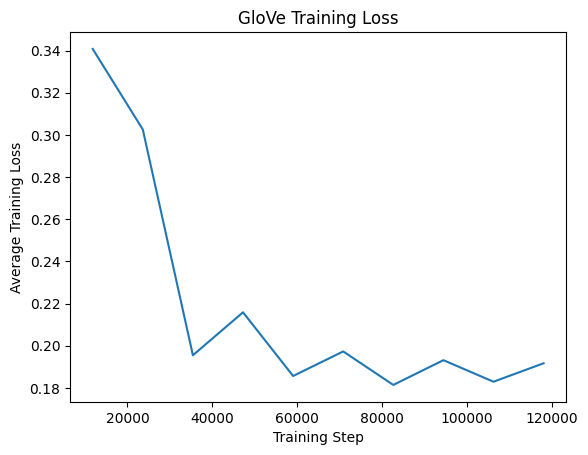

In [ ]:
# TODO(student): start

lr = best_lr  # Learning rate (fixed) - from experiment 1
checkpoint_model_path = "exp_2_setting_3" # Path to save checkpoints
final_model_path = "exp_2_setting_3_final_model" # Path to save the final model and embeddings

# Experiment 2: Vary the window size
# You can run this with different window sizes (e.g., 2, 3, 5, 10)
window_size = 10

run_training(
    epochs=10,  # Number of epochs to train
    lr=lr,  # Learning rate
    checkpoint_model_path=checkpoint_model_path,  # Directory to save model checkpoints
    final_model_path=final_model_path,  # Directory to save the final model and embeddings
    vocab_size=int(1e5),  # Vocabulary size
    batch_size=512,  # Batch size for training
    embedding_size=128,  # Embedding size (vector dimension)
    window_size=window_size,  # Context window size for co-occurrence
    checkpoint_step=5000,  # Save checkpoints after every 2000 steps
)

# TODO(student): end


<b> What is the best window_size for the GloVe model and why? What did you learn from the plots? </b>

TODO(students): start

The best window_size is 10. because from the above experiments, as window_size increases, the avg total loss of glove model decreases.
From plots, the avg loss of each epoch is decreasing. initially, since weight vectors are totally untrained, the avg loss is high in each experiment for the first epoch. And then, avg loss decreases slowly through each epoch. So, as epoch's increases, the avg loss decreases from the above plots.

TODO(students): end

In [ ]:
## TODO(students): start

best_window_size = 10

## TODO(students): end

### Experiment 3

For Experiment 3 in the GloVe model, we will set the best learning rate and window size from the previous experiments (Experiments 1 and 2). Now, we will vary the embedding size to explore how the dimensionality of the word vectors affects the quality of the embeddings.

#### Hyperparameter Setting 1 for Experiment 3

Created path: exp_3_setting_1_glove/
Most common words (+UNK) [['UNK', 0], ('the', 62827), ('of', 36789), ('and', 25238), ('one', 24679)]
Sample data: [632, 3668, 12, 6, 173, 2, 4288, 47, 63, 150] ['anarchism', 'originated', 'as', 'a', 'term', 'of', 'abuse', 'first', 'used', 'against']
Generating co-occurrence matrix...
Building cooccurrence matrix: on line 0/1000000
Building cooccurrence matrix: on line 100000/1000000
Building cooccurrence matrix: on line 200000/1000000
Building cooccurrence matrix: on line 300000/1000000
Building cooccurrence matrix: on line 400000/1000000
Building cooccurrence matrix: on line 500000/1000000
Building cooccurrence matrix: on line 600000/1000000
Building cooccurrence matrix: on line 700000/1000000
Building cooccurrence matrix: on line 800000/1000000
Building cooccurrence matrix: on line 900000/1000000
Co-occurrence matrix generated.
Printing Validation Set Words
Word: name, ID: 97
Word: with, ID: 24
Word: years, ID: 86
Word: states, ID: 76
Word: their,

Epoch 1/10: 100%|██████████| 11804/11804 [00:52<00:00, 222.88it/s, Batch Loss=0.0647, Avg Loss=0.0606]


Epoch 1 completed - Average Loss: 0.1618
Checkpoint saved at step 11804 to exp_3_setting_1_glove//glove_model_step_11804.pt
Printing closest words
name: ['themselves', 'precede', 'UNK', 'tuned', 'assented', 'UNK', 'mai', 'hemolitic']
with: ['have', 'for', 'six', 'UNK', 'is', 'UNK', 'from', 'national']
years: ['bonaduce', 'UNK', 'UNK', 'UNK', 'UNK', 'john', 'UNK', 'UNK']
states: ['miyazawa', 'then', 'convergence', 'dawkins', 'multidimensional', 'parma', 'strabo', 'lordly']
their: ['omnium', 'roxb', 'UNK', 'UNK', 'retaliated', 'UNK', 'bit', 'UNK']
people: ['UNK', 'algerie', 'valois', 'asexual', 'UNK', 'UNK', 'yury', 'centaurus']
when: ['undertakings', 'disjointed', 'saintcharlesalgiers', 'UNK', 'under', 'UNK', 'urs', 'UNK']
in: ['most', 'open', 's', 'UNK', 'UNK', 'semitism', 'national', 'auditory']
three: ['UNK', 'for', 'gunma', 'townspeople', 'is', 'two', 'UNK', 'frugal']
between: ['moved', 'UNK', 'rj', 'lines', 'UNK', 'deerfoot', 'lower', 'jure']
some: ['UNK', 'coachella', 'twinkies', 

Epoch 2/10: 100%|██████████| 11804/11804 [00:52<00:00, 223.29it/s, Batch Loss=0.146, Avg Loss=0.0849]


Epoch 2 completed - Average Loss: 0.0798
Checkpoint saved at step 23608 to exp_3_setting_1_glove//glove_model_step_23608.pt
Printing closest words
name: ['she', 'we', 'now', 'both', 'could', 'still', 'each', 'than']
with: ['UNK', 'for', 'galactics', 'scotty', 'UNK', 'UNK', 'praeger', 'reclusive']
years: ['more', 'then', 'only', 'people', 'her', 'general', 'had', 'the']
states: ['then', 'no', 'often', 'works', 'people', 'between', 'different', 'sometimes']
their: ['which', 'known', 'however', 'has', 'he', 'new', 'all', 'not']
people: ['between', 'about', 'years', 'often', 'no', 'city', 'her', 'only']
when: ['most', 'into', 'made', 'using', 'term', 'change', 'distinct', 'UNK']
in: ['to', 'many', 'was', 'and', 'of', 'world', 'zero', 'city']
three: ['victory', 'the', 'named', 'small', 'show', 'novel', 'long', 'any']
between: ['her', 'no', 'death', 'people', 'north', 'long', 'often', 'well']
some: ['such', 'been', 'had', 'more', 'only', 'can', 'also', 'large']
who: ['after', 'had', 'been', 

...

Epoch 8 completed - Average Loss: 0.0587
Checkpoint saved at step 94432 to exp_3_setting_1_glove//glove_model_step_94432.pt
Printing closest words
name: ['may', 'i', 'both', 'ii', 'history', 'them', 'through', 'those']
with: ['and', 'as', 'two', 's', 'khair', 'flounders', 'belle', 'blackmail']
years: ['no', 'them', 'year', 'world', 'him', 'even', 'states', 'name']
states: ['people', 'him', 'history', 'world', 'them', 'then', 'may', 'war']
their: ['its', 'but', 'which', 'this', 'similar', 'have', 'use', 'under']
people: ['history', 'states', 'all', 'no', 'has', 'him', 'g', 'first']
when: ['being', 'up', 'there', 'time', 'at', 'however', 'also', 'have']
in: ['to', 'zero', 'nine', 'was', 'eight', 'of', 'seven', 'a']
three: ['five', 'is', 'or', 'six', 'such', 'dulfer', 'rrna', 's']
between: ['b', 'called', 'about', 'later', 'UNK', 'UNK', 'UNK', 'tranquilliser']
some: ['leeks', 'would', 'UNK', 'were', 'UNK', 'UNK', 'dengizik', 'sucinum']
who: ['would', 'over', 'example', 'just', 'though', '

Epoch 9/10: 100%|██████████| 11804/11804 [00:53<00:00, 220.86it/s, Batch Loss=0.0979, Avg Loss=0.0706]


Epoch 9 completed - Average Loss: 0.0586
Checkpoint saved at step 106236 to exp_3_setting_1_glove//glove_model_step_106236.pt
Printing closest words
name: ['her', 'still', 'both', 'those', 'then', 'reigned', 'does', 'written']
with: ['fetched', 'thrillers', 'samaritan', 'infidelity', 'listeria', 'UNK', 'vaishashik', 'electrolytic']
years: ['even', 'no', 'year', 'states', 'world', 'war', 'model', 'him']
states: ['even', 'no', 'years', 'set', 'fact', 'him', 'year', 'space']
their: ['he', 'its', 'at', 'UNK', 'UNK', 'UNK', 'UNK', 'apok']
people: ['can', 'all', 'may', 'i', 'history', 'not', 'about', 'some']
when: ['see', 'called', 'either', 'however', 'held', 'view', 'popular', 'cases']
in: ['to', 'a', 'of', 'would', 'nine', 'large', 'aiwass', 'god']
three: ['five', 'is', 'as', 'six', 'that', 'one', 'by', 'two']
between: ['them', 'made', 'called', 'b', 'see', 'shape', 'when', 'make']
some: ['who', 'used', 'it', 'all', 'not', 'i', 'same', 'they']
who: ['some', 'all', 'used', 'about', 'not', 

Epoch 10/10: 100%|██████████| 11804/11804 [00:53<00:00, 221.37it/s, Batch Loss=0.0758, Avg Loss=0.0706]


Epoch 10 completed - Average Loss: 0.0578
Checkpoint saved at step 118040 to exp_3_setting_1_glove//glove_model_step_118040.pt
Printing closest words
name: ['still', 'then', 'those', 'often', 'them', 'both', 'having', 'same']
with: ['he', 'or', 'which', 'eight', 'also', 'such', 'but', 'seven']
years: ['him', 'them', 'later', 'states', 'called', 'often', 'world', 'when']
states: ['him', 'when', 'world', 'called', 'between', 'them', 'also', 'but']
their: ['its', 'kalvik', 'reforms', 'UNK', 'UNK', 'return', 'UNK', 'declarations']
people: ['all', 'well', 'i', 'sometimes', 'so', 'found', 'd', 'glaucescens']
when: ['called', 'between', 'states', 'them', 'often', 'later', 'see', 'but']
in: ['a', 'to', 's', 'they', 'for', 'with', 'zero', 'four']
three: ['city', 'six', 'during', 'first', 'article', 'nine', 'UNK', 'september']
between: ['when', 'them', 'called', 'states', 'later', 'b', 'see', 'him']
some: ['UNK', 'pneuma', 'exhibiting', 'hurting', 'leading', 'besides', 'revolte', 'engage']
who: 

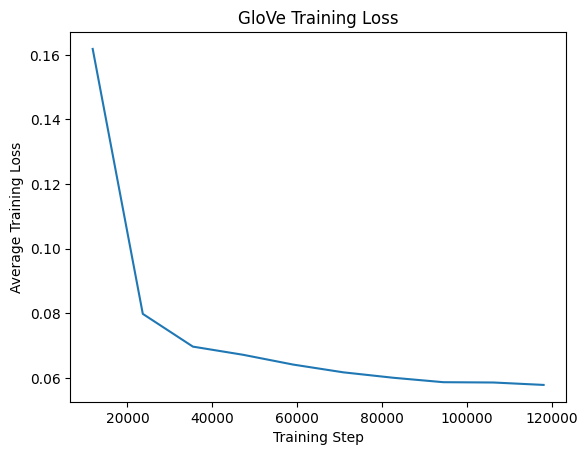

In [ ]:
# TODO(student): start

#use best_lr & best_window_size (from previous experiments)
lr = best_lr
window_size = best_window_size

checkpoint_model_path = "exp_3_setting_1"  # Path to save checkpoints
final_model_path =  "exp_3_setting_1_final_model" # Path to save the final model and embeddings

# Experiment 3: Vary the embedding size
# Try different embedding sizes like 50, 128, 300 to observe how it affects the embeddings
embedding_size = 50

run_training(
    epochs=10,  # Number of epochs to train
    lr=lr,  # Best learning rate from Experiment 1
    checkpoint_model_path=checkpoint_model_path,  # Directory to save model checkpoints
    final_model_path=final_model_path,  # Directory to save the final model and embeddings
    vocab_size=int(1e5),  # Vocabulary size (fixed)
    batch_size=512,  # Batch size for training (fixed)
    embedding_size=embedding_size,  # Vary this parameter for different runs (e.g., 50, 128, 300)
    window_size=window_size,  # Best window size from Experiment 2
    checkpoint_step=5000,  # Save checkpoints after every 2000 steps
)

# TODO(student): end


#### Hyperparameter Setting 2 for Experiment 2

Created path: exp_3_setting_2_glove/
Most common words (+UNK) [['UNK', 0], ('the', 62827), ('of', 36789), ('and', 25238), ('one', 24679)]
Sample data: [632, 3668, 12, 6, 173, 2, 4288, 47, 63, 150] ['anarchism', 'originated', 'as', 'a', 'term', 'of', 'abuse', 'first', 'used', 'against']
Generating co-occurrence matrix...
Building cooccurrence matrix: on line 0/1000000
Building cooccurrence matrix: on line 100000/1000000
Building cooccurrence matrix: on line 200000/1000000
Building cooccurrence matrix: on line 300000/1000000
Building cooccurrence matrix: on line 400000/1000000
Building cooccurrence matrix: on line 500000/1000000
Building cooccurrence matrix: on line 600000/1000000
Building cooccurrence matrix: on line 700000/1000000
Building cooccurrence matrix: on line 800000/1000000
Building cooccurrence matrix: on line 900000/1000000
Co-occurrence matrix generated.
Printing Validation Set Words
Word: was, ID: 15
Word: being, ID: 99
Word: into, ID: 62
Word: world, ID: 66
Word: has, ID:

Epoch 1/10: 100%|██████████| 11804/11804 [01:02<00:00, 189.06it/s, Batch Loss=0.134, Avg Loss=0.153]


Epoch 1 completed - Average Loss: 0.3330
Checkpoint saved at step 11804 to exp_3_setting_2_glove//glove_model_step_11804.pt
Printing closest words
was: ['that', 'music', 'as', 's', 'of', 'their', 'braunau', 'often']
being: ['he', 'called', 'rather', 'commonly', 'UNK', 'music', 'blyth', 'UNK']
into: ['with', 'any', 'be', 'empire', 'ecclesial', 'is', 'english', 'for']
world: ['UNK', 'related', 'manga', 'iona', 'UNK', 'UNK', 'openstep', 'UNK']
has: ['different', 'though', 'zero', 'orients', 'war', 'UNK', 'UNK', 'alternate']
were: ['are', 'which', 'but', 'an', 'einstein', 'region', 'such', 'side']
united: ['cranmer', 'nassenes', 'UNK', 'cgpm', 'UNK', 'UNK', 'an', 'UNK']
this: ['some', 'may', 'number', 'result', 'messina', 'alternate', 'general', 'about']
so: ['auberon', 'UNK', 'called', 'states', 'rasis', 'west', 'number', 'fooled']
b: ['for', 'd', 'their', 'french', 'american', 'new', 'who', 'between']
it: ['UNK', 'between', 'this', 'like', 'he', 'war', 'not', 'body']
as: ['s', 'was', 'th

Epoch 2/10: 100%|██████████| 11804/11804 [01:02<00:00, 188.32it/s, Batch Loss=1.18, Avg Loss=0.633]


Epoch 2 completed - Average Loss: 0.2985
Checkpoint saved at step 23608 to exp_3_setting_2_glove//glove_model_step_23608.pt
Printing closest words
was: ['on', 'their', 'in', 'influence', 'are', 'catholic', 'terms', 'anime']
being: ['any', 'this', 'century', 'take', 'made', 'about', 'greek', 'based']
into: ['which', 'with', 'first', 'the', 'all', 'five', 'over', 'united']
world: ['such', 'than', 'their', 'where', 'which', 'great', 'life', 'death']
has: ['be', 'most', 'been', 'war', 'not', 'other', 'however', 'against']
were: ['be', 's', 'not', 'government', 'on', 'however', 'are', 'was']
united: ['over', 'all', 'during', 'than', 'such', 'first', 'state', 'life']
this: ['some', 'any', 'that', 'being', 'have', 'may', 'word', 'had']
so: ['given', 'total', 'william', 'british', 'making', 'down', 'could', 'based']
b: ['some', 'general', 'american', 'that', 'i', 'this', 'five', 'first']
it: ['support', 'who', 'british', 'based', 'd', 'but', 'similar', 'current']
as: ['s', 'be', 'most', 'are',

...

Epoch 8 completed - Average Loss: 0.1895
Checkpoint saved at step 94432 to exp_3_setting_2_glove//glove_model_step_94432.pt
Printing closest words
was: ['by', 'three', 'as', 'eight', 'that', 'also', 'be', 'five']
being: ['only', 'over', 'where', 'even', 'them', 'just', 'no', 'may']
into: ['about', 'england', 'make', 'school', 'production', 'took', 'under', 'high']
world: ['known', 'some', 'had', 'all', 'been', 'more', 'however', 'name']
has: ['there', 'many', 'their', 'most', 'first', 'other', 'way', 'these']
were: ['he', 'are', 'it', 'from', 'his', 'by', 'more', 's']
united: ['states', 'all', 'world', 'm', 'american', 'some', 'used', 'd']
this: ['s', 'six', 'an', 'it', 'for', 'seven', 'which', 'have']
so: ['known', 'then', 'each', 'do', 'those', 'own', 'world', 'century']
b: ['there', 'him', 'most', 'has', 'way', 'first', 'such', 'x']
it: ['s', 'his', 'more', 'have', 'are', 'had', 'some', 'world']
as: ['was', 'by', 'be', 'that', 'eight', 'in', 'three', 'and']
no: ['only', 'even', 'par

Epoch 9/10: 100%|██████████| 11804/11804 [01:03<00:00, 187.28it/s, Batch Loss=0.423, Avg Loss=0.441]


Epoch 9 completed - Average Loss: 0.1831
Checkpoint saved at step 106236 to exp_3_setting_2_glove//glove_model_step_106236.pt
Printing closest words
was: ['two', 'to', 'had', 'years', 'of', 'that', 'for', 'four']
being: ['UNK', 'animations', 'over', 'UNK', 'parents', 'africa', 'UNK', 'easter']
into: ['i', 'their', 'most', 'about', 'see', 'if', 'were', 'during']
world: ['states', 'some', 'more', 'early', 'much', 'same', 'century', 'when']
has: ['not', 'their', 'most', 'other', 'first', 'on', 'he', 'at']
were: ['not', 'other', 'than', 'i', 'which', 'on', 'their', 'had']
united: ['word', 'more', 'so', 'french', 'large', 'government', 'often', 'some']
this: ['UNK', 'UNK', 'guggenheim', 'bloodier', 'kingdom', 'UNK', 'in', 'wok']
so: ['more', 'modern', 'some', 'do', 'much', 'century', 'another', 'government']
b: ['nobel', 'actor', 'nine', 'seven', 'immensely', 'allende', 'physicist', 'two']
it: ['from', 'are', 'december', 'UNK', 'indiscriminately', 'russia', 'lens', 'amingdola']
as: ['a', 'n

Epoch 10/10: 100%|██████████| 11804/11804 [01:03<00:00, 187.03it/s, Batch Loss=0.812, Avg Loss=0.491]


Epoch 10 completed - Average Loss: 0.1910
Checkpoint saved at step 118040 to exp_3_setting_2_glove//glove_model_step_118040.pt
Printing closest words
was: ['three', 'eight', 'as', 'by', 'in', 'it', 's', 'and']
being: ['out', 'built', 'l', 'them', 'through', 'earth', 'region', 'using']
into: ['about', 'th', 'most', 'during', 'however', 'over', 'has', 'times']
world: ['states', 'known', 'had', 'music', 'another', 'been', 'all', 'before']
has: ['most', 'first', 'which', 'during', 's', 'into', 'if', 'th']
were: ['had', 'all', 'its', 'their', 'been', 'not', 'see', 'world']
united: ['french', 'while', 'early', 'time', 'when', 'film', 'will', 'more']
this: ['from', 'it', 's', 'and', 'has', 'but', 'b', 'his']
so: ['century', 'people', 'jewish', 'end', 'based', 'modern', 'together', 'believe']
b: ['such', 'many', 'there', 'also', 'it', 'however', 'back', 'could']
it: ['be', 'also', 'as', 'by', 's', 'was', 'but', 'eight']
as: ['by', 'was', 'eight', 'three', 'it', 's', 'in', 'and']
no: ['these', 

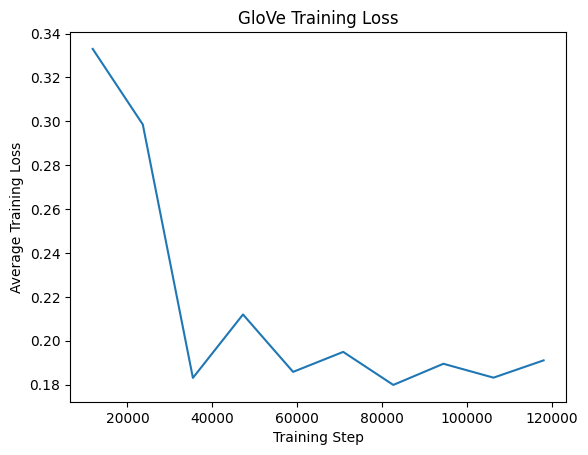

In [ ]:
# TODO(student): start

#use best_lr & best_window_size (from previous experiments)
lr = best_lr
window_size = best_window_size

checkpoint_model_path = "exp_3_setting_2"  # Path to save checkpoints
final_model_path = "exp_3_setting_2_final_model"  # Path to save the final model and embeddings

# Experiment 3: Vary the embedding size
# Try different embedding sizes like 50, 128, 300 to observe how it affects the embeddings
embedding_size = 128

run_training(
    epochs=10,  # Number of epochs to train
    lr=lr,  # Best learning rate from Experiment 1
    checkpoint_model_path=checkpoint_model_path,  # Directory to save model checkpoints
    final_model_path=final_model_path,  # Directory to save the final model and embeddings
    vocab_size=int(1e5),  # Vocabulary size (fixed)
    batch_size=512,  # Batch size for training (fixed)
    embedding_size=embedding_size,  # Vary this parameter for different runs (e.g., 50, 128, 300)
    window_size=window_size,  # Best window size from Experiment 2
    checkpoint_step=5000,  # Save checkpoints after every 2000 steps
)

# TODO(student): end


#### Hyperparameter Setting 3 for Experiment 3

Created path: exp_3_setting_3_glove/
Most common words (+UNK) [['UNK', 0], ('the', 62827), ('of', 36789), ('and', 25238), ('one', 24679)]
Sample data: [632, 3668, 12, 6, 173, 2, 4288, 47, 63, 150] ['anarchism', 'originated', 'as', 'a', 'term', 'of', 'abuse', 'first', 'used', 'against']
Generating co-occurrence matrix...
Building cooccurrence matrix: on line 0/1000000
Building cooccurrence matrix: on line 100000/1000000
Building cooccurrence matrix: on line 200000/1000000
Building cooccurrence matrix: on line 300000/1000000
Building cooccurrence matrix: on line 400000/1000000
Building cooccurrence matrix: on line 500000/1000000
Building cooccurrence matrix: on line 600000/1000000
Building cooccurrence matrix: on line 700000/1000000
Building cooccurrence matrix: on line 800000/1000000
Building cooccurrence matrix: on line 900000/1000000
Co-occurrence matrix generated.
Printing Validation Set Words
Word: four, ID: 21
Word: and, ID: 3
Word: when, ID: 67
Word: or, ID: 29
Word: two, ID: 11
W

Epoch 1/10: 100%|██████████| 11804/11804 [01:19<00:00, 147.73it/s, Batch Loss=0.335, Avg Loss=0.444]


Epoch 1 completed - Average Loss: 0.8164
Checkpoint saved at step 11804 to exp_3_setting_3_glove//glove_model_step_11804.pt
Printing closest words
four: ['was', 'had', 'six', 'war', 'legal', 'two', 'abledata', 'work']
and: ['zero', 'a', 'poles', 'three', 'under', 'were', 'or', 'prentice']
when: ['people', 'UNK', 'free', 'as', 'zero', 'such', 'movement', 'conocophillips']
or: ['zero', 'as', 'cannes', 'to', 'committees', 'and', 'UNK', 'UNK']
two: ['three', 'this', 'national', 'her', 'part', 'much', 'eight', 'australia']
eight: ['since', 'less', 'two', 'like', 'ii', 'UNK', 'this', 'australia']
th: ['may', 'father', 'made', 'will', 'this', 'its', 'also', 'which']
its: ['people', 'single', 'used', 'other', 'will', 'since', 'been', 'never']
in: ['to', 'zero', 'two', 'three', 's', 'as', 'an', 'for']
all: ['great', 'he', 'were', 'it', 'live', 'down', 'later', 'two']
only: ['could', 'do', 'under', 'time', 'both', 'being', 'although', 'present']
seven: ['an', 'their', 'has', 'two', 'he', 'nation

Epoch 2/10: 100%|██████████| 11804/11804 [01:20<00:00, 147.04it/s, Batch Loss=8.15, Avg Loss=4.28]


Epoch 2 completed - Average Loss: 1.8515
Checkpoint saved at step 23608 to exp_3_setting_3_glove//glove_model_step_23608.pt
Printing closest words
four: ['five', 'as', 'state', 'used', 'for', 'at', 'with', 'who']
and: ['to', 'in', 'of', 'at', 'while', 'five', 'found', 'time']
when: ['i', 'states', 'known', 'first', 'there', 'for', 'have', 'be']
or: ['from', 'for', 'at', 'with', 'be', 'have', 'are', 'five']
two: ['by', 'was', 'three', 'stressful', 'UNK', 'priests', 'UNK', 'UNK']
eight: ['knights', 'climate', 'vendsyssel', 'UNK', 'psychoanal', 'ein', 'military', 'duncan']
th: ['national', 'use', 'important', 'union', 'very', 'australia', 'city', 'generally']
its: ['have', 'first', 'be', 'who', 'more', 'or', 'can', 'from']
in: ['to', 'and', 'as', 'while', 'time', 'at', 'number', 'best']
all: ['it', 'time', 'some', 'while', 'most', 'had', 'using', 'early']
only: ['i', 'into', 'general', 'great', 'much', 'at', 'known', 'history']
seven: ['is', 'three', 'maric', 'UNK', 'majority', 'UNK', 'ze

...

Epoch 8 completed - Average Loss: 0.9979
Checkpoint saved at step 94432 to exp_3_setting_3_glove//glove_model_step_94432.pt
Printing closest words
four: ['on', 'five', 'his', 'or', 'an', 'which', 'zero', 'not']
and: ['the', 'of', 'a', 'to', 'with', 'six', 'this', 'have']
when: ['copies', 'tretow', 'lobes', 'UNK', 'paleolithic', 'UNK', 'aias', 'wetumpka']
or: ['on', 'his', 'which', 'an', 'five', 'four', 'zero', 'this']
two: ['one', 'and', 'veer', 'nine', 'for', 'shyness', 'UNK', 'paucifolia']
eight: ['by', 'are', 'in', 'people', 'general', 'who', 'mostly', 'waves']
th: ['through', 'name', 'day', 'states', 'well', 'year', 'century', 'much']
its: ['been', 'also', 'which', 'have', 'they', 'were', 'or', 'but']
in: ['by', 'are', 'eight', 'has', 'law', 'member', 'all', 'result']
all: ['are', 'has', 'in', 'arthurcclarke', 'those', 'called', 'there', 'balto']
only: ['than', 'new', 'however', 'after', 'but', 'have', 'war', 'been']
seven: ['six', 'on', 'his', 'five', 'which', 'have', 'with', 'thi

Epoch 9/10: 100%|██████████| 11804/11804 [01:20<00:00, 146.02it/s, Batch Loss=2.72, Avg Loss=2.5]


Epoch 9 completed - Average Loss: 0.8796
Checkpoint saved at step 106236 to exp_3_setting_3_glove//glove_model_step_106236.pt
Printing closest words
four: ['also', 'on', 'the', 'other', 'it', 'by', 'that', 'were']
and: ['the', 'of', 'a', 'to', 'in', 'was', 'from', 'on']
when: ['more', 'first', 'there', 'most', 'known', 'that', 'by', 'all']
or: ['are', 'when', 'norfolk', 'empire', 'arrhenius', 'by', 'hypothesized', 'rope']
two: ['as', 'by', 'was', 'eight', 'that', 'are', 'it', 'from']
eight: ['by', 'that', 'was', 'in', 'from', 'are', 'it', 'as']
th: ['day', 'what', 'century', 'art', 'often', 'series', 'apollo', 'atheism']
its: ['an', 'swallowing', 'have', 'this', 'degradation', 'desalination', 'UNK', 'alone']
in: ['eight', 'the', 'by', 'was', 'that', 'of', 'are', 'and']
all: ['first', 'most', 'were', 'such', 'it', 'other', 'time', 'who']
only: ['war', 'than', 'were', 'about', 'if', 'many', 'considered', 'found']
seven: ['with', 'have', 'six', 'an', 'their', 'what', 'stimulations', 'this

Epoch 10/10: 100%|██████████| 11804/11804 [01:20<00:00, 146.36it/s, Batch Loss=4.36, Avg Loss=3.19]


Epoch 10 completed - Average Loss: 1.0077
Checkpoint saved at step 118040 to exp_3_setting_3_glove//glove_model_step_118040.pt
Printing closest words
four: ['was', 'in', 'from', 'book', 'on', 'not', 'would', 'thys']
and: ['the', 'of', 'a', 'to', 'two', 'be', 'are', 'were']
when: ['there', 'first', 'united', 'most', 'made', 'so', 'use', 'under']
or: ['an', 'seven', 's', 'are', 'two', 'he', 'have', 'to']
two: ['to', 's', 'is', 'seven', 'or', 'a', 'an', 'be']
eight: ['is', 'two', 'as', 'zero', 'a', 'to', 's', 'an']
th: ['up', 'out', 'both', 'm', 'film', 'south', 'early', 'including']
its: ['have', 'has', 'been', 'an', 'or', 'be', 'into', 'were']
in: ['was', 'four', 'from', 'not', 'over', 'UNK', 'could', 'that']
all: ['were', 'they', 'six', 'first', 'a', 'to', 'two', 'most']
only: ['when', 'most', 'her', 'work', 'were', 'first', 'm', 'there']
seven: ['an', 'he', 'or', 'be', 'two', 'six', 's', 'have']
also: ['are', 'were', 'he', 'at', 'six', 'or', 'to', 'an']
can: ['they', 'were', 'area', '

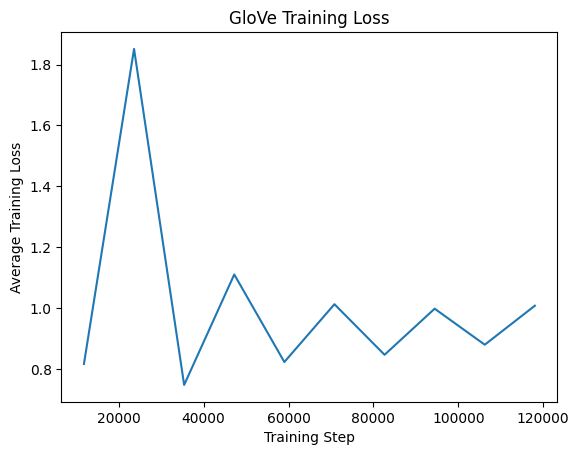

In [ ]:
# TODO(student): start

#use best_lr & best_window_size (from previous experiments)
lr = best_lr
window_size = best_window_size

checkpoint_model_path = "exp_3_setting_3"  # Path to save checkpoints
final_model_path =  "exp_3_setting_3_final_model" # Path to save the final model and embeddings

# Experiment 3: Vary the embedding size
# Try different embedding sizes like 50, 128, 300 to observe how it affects the embeddings
embedding_size = 300

run_training(
    epochs=10,  # Number of epochs to train
    lr=lr,  # Best learning rate from Experiment 1
    checkpoint_model_path=checkpoint_model_path,  # Directory to save model checkpoints
    final_model_path=final_model_path,  # Directory to save the final model and embeddings
    vocab_size=int(1e5),  # Vocabulary size (fixed)
    batch_size=512,  # Batch size for training (fixed)
    embedding_size=embedding_size,  # Vary this parameter for different runs (e.g., 50, 128, 300)
    window_size=window_size,  # Best window size from Experiment 2
    checkpoint_step=5000,  # Save checkpoints after every 2000 steps
)

# TODO(student): end


<b> What is the best embedding size to use for GloVe model and why? What did you learn from the plots? </b>

TODO(students): start

Best embedding size is 50 because the avg total loss of all experiments is less for embedding size when it is 50 than 128 and 300. And from plots, for emb_size = 50, the avgtotal loss is decreasing gradually through the experiment. For other embedding experiments, the overall loss is decreasing but for each epoch, the avg loss is first increasing and then decreasing. It shows that the weights are already in stable state so for next epoch, the avg loss is first increasing and then decreasing more than prev epoch. So, we cannot much change the avg loss for emb_size = 128 and 300.

TODO(students): end

In [ ]:
## TODO(students): start

best_embedding_size = 50

## TODO(students): end

### Training the best models

Now, you should use the best hyperparameter settings for the above three experiments to train your best GloVe model.

Created path: best_params_model_settings_glove/
Most common words (+UNK) [['UNK', 0], ('the', 62827), ('of', 36789), ('and', 25238), ('one', 24679)]
Sample data: [632, 3668, 12, 6, 173, 2, 4288, 47, 63, 150] ['anarchism', 'originated', 'as', 'a', 'term', 'of', 'abuse', 'first', 'used', 'against']
Generating co-occurrence matrix...
Building cooccurrence matrix: on line 0/1000000
Building cooccurrence matrix: on line 100000/1000000
Building cooccurrence matrix: on line 200000/1000000
Building cooccurrence matrix: on line 300000/1000000
Building cooccurrence matrix: on line 400000/1000000
Building cooccurrence matrix: on line 500000/1000000
Building cooccurrence matrix: on line 600000/1000000
Building cooccurrence matrix: on line 700000/1000000
Building cooccurrence matrix: on line 800000/1000000
Building cooccurrence matrix: on line 900000/1000000
Co-occurrence matrix generated.
Printing Validation Set Words
Word: world, ID: 66
Word: its, ID: 46
Word: has, ID: 41
Word: he, ID: 32
Word: w

Epoch 1/10: 100%|██████████| 11804/11804 [00:52<00:00, 223.62it/s, Batch Loss=0.0467, Avg Loss=0.0604]


Epoch 1 completed - Average Loss: 0.1712
Checkpoint saved at step 11804 to best_params_model_settings_glove//glove_model_step_11804.pt
Printing closest words
world: ['m', 'for', 'ethereal', 'control', 'his', 'population', 'because', 'an']
its: ['four', 'an', 'lttl', 'absolute', 'because', 'taxonomists', 'fiction', 'pyloric']
has: ['bonaparte', 'their', 'bureaucrat', 'UNK', 'for', 'UNK', 'not', 'UNK']
he: ['were', 'such', 'this', 'water', 'other', 'pareja', 'nivat', 'both']
war: ['murch', 'system', 'if', 'messianic', 'this', 'apex', 'contians', 'UNK']
they: ['no', 'this', 'UNK', 'chlorus', 'last', 'UNK', 'cyrus', 'UNK']
the: ['diablerie', 'opossum', 'UNK', 'adjudged', 'anabaptist', 'UNK', 'ounces', 'UNK']
all: ['before', 'are', 'this', 'germany', 'based', 'b', 'UNK', 'it']
most: ['real', 'system', 'saltpetre', 'scofield', 'UNK', 'UNK', 'UNK', 'marshalling']
would: ['UNK', 'UNK', 'aloud', 'gaps', 'before', 'bc', 'scion', 'UNK']
two: ['on', 'm', 'four', 'that', 'of', 'an', 'have', 'as']
w

Epoch 2/10: 100%|██████████| 11804/11804 [00:53<00:00, 222.61it/s, Batch Loss=0.138, Avg Loss=0.0835]


Epoch 2 completed - Average Loss: 0.0832
Checkpoint saved at step 23608 to best_params_model_settings_glove//glove_model_step_23608.pt
Printing closest words
world: ['m', 'personal', 'existence', 'because', 'phenomenon', 'translated', 'like', 'classic']
its: ['UNK', 'land', 'masoleum', 'UNK', 'UNK', 'theory', 'hush', 'UNK']
has: ['their', 'which', 'first', 'been', 'five', 'name', 'when', 'can']
he: ['from', 'usually', 'law', 'a', 'roman', 'it', 'was', 'america']
war: ['john', 'famous', 'part', 'true', 'UNK', 'sometimes', 'other', 'UNK']
they: ['this', 'any', 'god', 'while', 'after', 'how', 'usually', 'first']
the: ['also', 'under', 'usually', 'human', 'roman', 'began', 'government', 'non']
all: ['are', 'data', 'each', 'law', 'unseeable', 'water', 'due', 'pixodarus']
most: ['well', 'sometimes', 'include', 'only', 'for', 'great', 'banastre', 'england']
would: ['only', 'far', 'will', 'than', 'should', 'do', 'lingerie', 'believe']
two: ['four', 'zero', 'is', 'one', 'at', 'through', 'austri

...

Epoch 8 completed - Average Loss: 0.0597
Checkpoint saved at step 94432 to best_params_model_settings_glove//glove_model_step_94432.pt
Printing closest words
world: ['over', 'since', 'will', 'see', 'new', 'near', 'around', 'through']
its: ['s', 'other', 'by', 'such', 'most', 'for', 'has', 'see']
has: ['but', 'most', 'by', 'after', 's', 'see', 'are', 'its']
he: ['that', 'were', 'be', 'diffuse', 'former', 'french', 'UNK', 'still']
war: ['th', 'links', 'first', 'still', 'during', 'another', 'any', 'among']
they: ['UNK', 'ti', 'UNK', 'used', 'managed', 'according', 'cowhorn', 'koskalos']
the: ['a', 'and', 'of', 'into', 'to', 'for', 'in', 's']
all: ['also', 'their', 'it', 'who', 'found', 'which', 'would', 'other']
most: ['by', 'has', 'but', 'for', 'are', 's', 'see', 'with']
would: ['where', 'their', 'which', 'than', 'have', 'found', 'all', 'them']
two: ['zero', 'nine', 'paulo', 'th', 'tomography', 'scheat', 'any', 'wellington']
was: ['by', 'as', 's', 'eight', 'five', 'three', 'for', 'are']


Epoch 9/10: 100%|██████████| 11804/11804 [00:53<00:00, 219.97it/s, Batch Loss=0.0967, Avg Loss=0.0706]


Epoch 9 completed - Average Loss: 0.0586
Checkpoint saved at step 106236 to best_params_model_settings_glove//glove_model_step_106236.pt
Printing closest words
world: ['since', 'over', 'there', 'state', 'him', 'had', 'known', 'nine']
its: ['UNK', 'spiders', 'UNK', 'platensis', 'this', 'hers', 'cec', 'seamlessly']
has: ['at', 'other', 'all', 'like', 'new', 'when', 'this', 'than']
he: ['that', 'his', 'two', 'nine', 'it', 'or', 'be', 'zero']
war: ['links', 'american', 'th', 'first', 'century', 'civil', 'german', 'film']
they: ['used', 'name', 'some', 'been', 'can', 'she', 'had', 'more']
the: ['in', 'a', 'and', 'that', 'one', 'it', 'or', 'he']
all: ['other', 'than', 'same', 'no', 'at', 'under', 'this', 'has']
most: ['use', 'would', 'some', 'who', 'also', 'been', 'could', 'there']
would: ['use', 'most', 'there', 'known', 'been', 'often', 'who', 'some']
two: ['nine', 'zero', 'seven', 'he', 'that', 'his', 'or', 'eight']
was: ['by', 'to', 'UNK', 'usually', 'configurations', 'UNK', 's', 'gamepl

Epoch 10/10: 100%|██████████| 11804/11804 [00:54<00:00, 218.16it/s, Batch Loss=0.0712, Avg Loss=0.0702]


Epoch 10 completed - Average Loss: 0.0567
Checkpoint saved at step 118040 to best_params_model_settings_glove//glove_model_step_118040.pt
Printing closest words
world: ['after', 'were', 'on', 'he', 'called', 'which', 'during', 'alexander']
its: ['all', 'other', 'their', 'has', 'have', 'this', 'such', 'although']
has: ['at', 'have', 'all', 'this', 'which', 'but', 'other', 'its']
he: ['his', 'are', 'on', 'were', 'five', 's', 'three', 'which']
war: ['during', 'name', 'about', 'years', 'history', 'used', 'british', 'number']
they: ['name', 'used', 'being', 'during', 'about', 'she', 'history', 'years']
the: ['of', 'to', 'a', 'in', 'and', 'on', 'for', 's']
all: ['have', 'has', 'other', 'at', 'this', 'their', 'its', 'but']
most: ['would', 'however', 'after', 'of', 'his', 'are', 'there', 'main']
would: ['however', 'most', 'government', 'there', 'for', 'are', 'so', 'she']
two: ['tiananmen', 'granvelle', 'revitalized', 'echolalia', 'phrixus', 'armonico', 'endogenous', 'filmmaker']
was: ['as', 'b

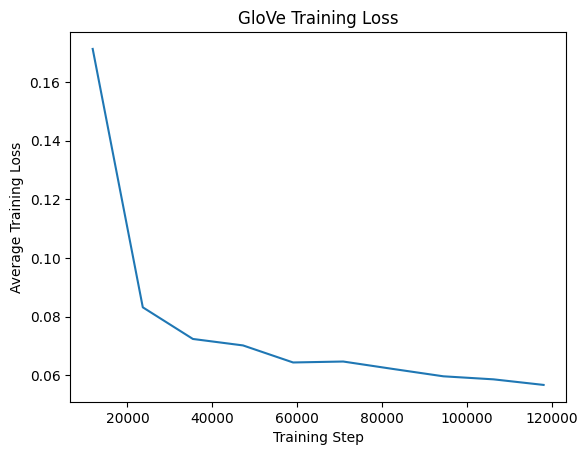

In [ ]:
# TODO(student): start

# Best hyperparameters identified from previous experiments
lr = best_lr  # Replace with the best learning rate identified
window_size = best_window_size # Replace with the best window size identified
embedding_size = best_embedding_size # Replace with the best embedding size identified

checkpoint_model_path = "best_params_model_settings"
final_model_path = "best_params_model"

# Training the best GloVe model with the identified hyperparameters
run_training(
    epochs=10,  # Train for more epochs to achieve better performance
    lr=lr,  # Best learning rate from previous experiments
    checkpoint_model_path=checkpoint_model_path,  # Directory to save model checkpoints
    final_model_path=final_model_path,  # Directory to save the final model and embeddings
    vocab_size=int(1e5),  # Vocabulary size (fixed)
    batch_size=512,  # Batch size for training (fixed)
    embedding_size=embedding_size,  # Best embedding size from previous experiments
    window_size=window_size,  # Best window size from previous experiments
    checkpoint_step=5000,  # Save checkpoints after every 5000 steps
)

# TODO(student): end


## Testing Framework

<b>Analogies using word vectors</b>

You will use the word vectors you learned from both approaches in the following word analogy task.

Each question/task is in the following form.
```
Consider the following word pairs that share the same relation, R:

    pilgrim:shrine, hunter:quarry, assassin:victim, climber:peak

Among these word pairs,

(1) pig:mud
(2) politician:votes
(3) dog:bone
(4) bird:worm

Q1. Which word pairs has the MOST illustrative(similar) example of the relation R?
Q2. Which word pairs has the LEAST illustrative(similar) example of the relation R?
```

For each question, there are examples pairs of a certain relation. Your task is to find the most/least illustrative word pair of the relation. One simple method to answer those questions will be measuring the similarities of difference vectors.

Recall that vectors are representing some direction in space. If (a, b) and (c, d) pairs are analogous pairs then the transformation from a to b (i.e., some x vector when added to a gives b: a + x = b) should be highly similar to the transformation from c to d (i.e., some y vector when added to c gives d: c + y = d). In other words, the difference vector (b-a) should be similar to difference vector (d-c).

This difference vector can be thought to represent the relation between the two words.

<b>Please fill-in the TODO section below to implement the above mentioned task.</b>

Due to the noisy annotation data, the expected accuracy is not high. You can use 33-36% as a general benchmark for GloVe's performance on the analogy task, aiming for improvements in that range.
Improving this score 1~3% would be your goal.


<b>Further implementation instructions:</b>

  - `In the next 2 cells`:
    You will write a code in the TODO section for evaluating relation between pairs of words -- called the [MaxDiff question](https://en.wikipedia.org/wiki/MaxDiff).
    You will generate a file with your predictions following the format of `word_analogy_sample_predictions.txt`.

  - `evaluate_word_analogy.pl`:
    This is a perl script to evaluate YOUR PREDICTIONS on development data. Use it as shown in the next cell. You do not need to submit prediction or score files related to the dev set.

  - `word_analogy_dev.txt`:
    This is some data for development.
    Each line of this file is divided into "examples" and "choices" by "||".
        [examples]||[choices]
    "Examples" and "choices" are delimited by a comma.
      For example:  "tailor:suit","oracle:prophesy","baker:flour"

  - `word_analogy_dev_sample_predictions.txt`:
    A sample prediction file. Pay attention to the format of this file.
    Your prediction file should follow this to use "score_maxdiff.pl" script.
    Each row is in this format:
    
      <pair1> <pair2> <pair3> <pair4> <least_illustrative_pair> <most_illustrative_pair>

    The order of word pairs should match their original order found in `word_analogy_dev.txt`.

  - `word_analogy_dev_mturk_answers.txt`:
    This is the answers collected using Amazon mechanical turk for `word_analogy_dev.txt`.
    The answers in this file is used as the correct answer and used to evaluate your analogy predictions. (using "evaluate_word_analogy.pl")
    For your information, the answers here are a little bit noisy.

  - `word_analogy_test.txt`:
    Test data file. When you are done experimenting with your model, you will generate predictions for this test data using your best model.
    You will not be able to run the evaluation script on the test set.

    Make sure your submission files are named: `test_preds_glove.txt`


In [7]:
def read_data(file_path):
    with open(file_path,'r') as f:
        data = f.readlines()

    candidate, test = [], []
    for line in data:
        a, b = line.strip().split("||")
        a = [i[1:-1].split(":") for i in a.split(",")]
        b = [i[1:-1].split(":") for i in b.split(",")]
        candidate.append(a)
        test.append(b)

    return candidate, test

def get_embeddings(examples, embeddings, dictionary):
    """
    For the word pairs in the 'examples' array, fetch embeddings and return.
    """
    norm = np.sqrt(np.sum(np.square(embeddings), axis=1, keepdims=True))
    normalized_embeddings = embeddings / norm

    embs = []
    for line in examples:
        temp = []
        for pairs in line:
            word1, word2 = pairs[0], pairs[1]

            # Get embeddings for word1 and word2 or fall back to 'UNK'
            if word1 in dictionary:
                emb1 = normalized_embeddings[dictionary[word1]]
            else:
                emb1 = normalized_embeddings[dictionary['UNK']]

            if word2 in dictionary:
                emb2 = normalized_embeddings[dictionary[word2]]
            else:
                emb2 = normalized_embeddings[dictionary['UNK']]

            # Append both embeddings as a pair
            temp.append([emb1, emb2])
        embs.append(temp)

    #result = np.array(embs)
    result = np.array(embs, dtype=object)
    return result

def evaluate_pairs(candidate_embs, test_embs):

    """
    Write code to evaluate a relation between pairs of words.
    Find the best and worst pairs and return that.
    """

    best_pairs = []
    worst_pairs = []

    ### TODO(students): start

    for i in range(len(candidate_embs)):

        cand_diffs_list = []
        for pair in candidate_embs[i]:
            v1 = np.array(pair[0], dtype=float)
            v2 = np.array(pair[1], dtype=float)
            cand_diffs_list.append(v1 - v2)



        # difference between the word embeddings for each pair in the candidate & test sets
        candidate_diffs = np.mean(cand_diffs_list, axis=0)

        test_diffs_list = []
        for pair in test_embs[i]:
            v1 = np.array(pair[0], dtype=float)
            v2 = np.array(pair[1], dtype=float)
            test_diffs_list.append(v1 - v2)
        test_diffs = np.array(test_diffs_list, dtype=float)

        # compute the similarity
        numerator = np.dot(test_diffs, candidate_diffs)
        denominator = np.linalg.norm(test_diffs, axis=1) * np.linalg.norm(candidate_diffs)
        similarity = numerator / (denominator + 1e-9)

        # rank similarities with highest ranked first
        rank = np.argsort(similarity)[::-1]

        # identify the best and worst pairs
        best, worst = rank[0], rank[-1]

        # append to the respective lists
        best_pairs.append(best)
        worst_pairs.append(worst)

    ### TODO(students): end

    return best_pairs, worst_pairs

def write_solution(best_pairs, worst_pairs, test, path):

    """
    Write best and worst pairs to a file, that can be evaluated by evaluate_word_analogy.pl
    """

    ans = []
    for i, line in enumerate(test):
        temp = [f'"{pairs[0]}:{pairs[1]}"' for pairs in line]
        temp.append(f'"{line[worst_pairs[i]][0]}:{line[worst_pairs[i]][1]}"')
        temp.append(f'"{line[best_pairs[i]][0]}:{line[best_pairs[i]][1]}"')
        ans.append(" ".join(temp))

    with open(path, 'w') as f:
        f.write("\n".join(ans))

def run_word_analogy_eval_glove(
    model_path='./final_model',  # Path to the location where the GloVe model is stored
    input_filepath='word_analogy_dev.txt',  # Word analogy file to evaluate on
    output_filepath='word_analogy_glove_results.txt',  # Predicted results
):
    """
    Main function to evaluate GloVe embeddings on word analogy tasks.
    """
    print(f'Model file: {model_path}/glove_embeddings.pkl')
    model_filepath = os.path.join(model_path, 'glove_embeddings.pkl')

    with open(model_filepath, 'rb') as f:
      data = pickle.load(f)

    # Unpack the saved data
    dictionary = data['vocab_token_to_id']
    embeddings = data['center_embeddings']

    # Read the analogy data
    candidate, test = read_data(input_filepath)

    # Get embeddings for candidate and test examples
    candidate_embs = get_embeddings(candidate, embeddings, dictionary)
    test_embs = get_embeddings(test, embeddings, dictionary)

    # Evaluate the relationships between word pairs
    best_pairs, worst_pairs = evaluate_pairs(candidate_embs, test_embs)

    # Write the solution to the output file
    print(f'Output file: {output_filepath}')
    write_solution(best_pairs, worst_pairs, test, output_filepath)


Once the word_analogy code is complete with the TODO section, you can use the following function call to generate the results of the word analogy task.

In [13]:
!unzip "538-hw1-117411478-models.zip"

Archive:  538-hw1-117411478-models.zip
  inflating: glove_embeddings.pkl    
replace __MACOSX/._glove_embeddings.pkl? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: __MACOSX/._glove_embeddings.pkl  
  inflating: glove.model             
replace __MACOSX/._glove.model? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: __MACOSX/._glove.model  


In [23]:
run_word_analogy_eval_glove(
    model_path = './', # path to the location where the model being evaluated is stored
    input_filepath = 'word_analogy_dev.txt', # Word analogy file to evaluate on
    output_filepath = 'word_analogy_best_glove_dev_results.txt', # predicted results

)

Model file: .//glove_embeddings.pkl
Output file: word_analogy_best_glove_dev_results.txt


In [17]:
# test for word_analogy_test.txt

run_word_analogy_eval_glove(
    model_path = '', # path to the location where the model being evaluated is stored
    input_filepath = 'word_analogy_test.txt', # Word analogy file to evaluate on
    output_filepath = 'test_preds_glove.txt', # predicted results

)

Model file: /glove_embeddings.pkl
Output file: test_preds_glove.txt


The results can finally be converted into numeric metrics using the Perl script below. A demo score result is also provided for refernce.

In [ ]:
!chmod 777 evaluate_word_analogy.pl
!./evaluate_word_analogy.pl word_analogy_dev_mturk_answers.txt word_analogy_best_glove_dev_results.txt demo_score_glove.txt

reading the Mechanical Turk answers to MaxDiff questions word_analogy_dev_mturk_answers.txt ...
... read 914 unique MaxDiff questions ...
... done.
reading the MaxDiff answers to be evaluated word_analogy_best_glove_dev_results.txt ...
... read 914 answers ...
... done.
scoring the answers and writing a summary to demo_score_glove.txt ...
... done.


### Conclude the results of your experiments. Include a table in the notebook showing all your results.

TODO(students): start

| Exp No | learning rate | window_size | embed_size | Avg_total_loss | comment |
|:---:|:---:|:---:|:---:|:---:|:---:|
| 1.0(default) | 0.01 | 3 | 128 | 0.2741 | default settings |
| 1.1 | 0.05 | 3 | 128 | 91.7088 | loss exploding compared to default |
| 1.2 | 0.1 | 3 | 128 | 1344.1214 | loss exploding compared to 1.1
| 1.3 | 0.5 | 3 | 128 | 801748.5250 | loss exploding more compared to 1.2
| 2.1 | 0.01 | 2 | 128 | 0.2689 | best loss compared to default window size
| 2.2 | 0.01 | 5 | 128 | 0.2484 | loss decreased compared to 2.1
| 2.3 | 0.01 | 10 | 128 | 0.1916 | loss decreased compared to 2.2
| 3.1 | 0.01 | 10 | 50 | 0.0578 | best emb_size compared to 2.3(best of prev exp)
| 3.2 | 0.01 | 10 | 128 | 0.1910 | loss increasing compared to 3.1
| 3.3 | 0.01 | 10 | 300 | 0.8164 | loss increasing more compared to 3.3

TODO(students): end

<b> Please make sure that you also test your best model on word_analogy_test.txt </b>

## Sentiment Analysis using word vectors

Remember, we had built and evaluated a logistic regression model in Assignment 1 for the task of sentiment classification. Similar to the word vectors we have just trained, we will first download word vectors trained on much larger corpora, and then use them to perform sentiment classification, instead of using the pre-built CountVectorizer function we had used last time.

With a much smaller input vector size, we can still achieve similar performance.

In [ ]:
!wget http://nlp.stanford.edu/data/glove.6B.zip

--2026-02-28 20:44:43--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-02-28 20:44:43--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-02-28 20:44:44--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [ ]:
!unzip glove*.zip

Archive:  glove.6B.zip
  inflating: glove.6B.50d.txt        
  inflating: glove.6B.100d.txt       
  inflating: glove.6B.200d.txt       
  inflating: glove.6B.300d.txt       


In [ ]:
# load and index GloVe vectors for logistic regression experiments
def load_glove_vectors():
    embeddings = {}
    f = open('glove.6B.300d.txt', encoding='utf-8')
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings[word] = coefs
    f.close()

    print('Found %s word vectors.' % len(embeddings))

    return embeddings

In [ ]:
def generate_input_output_for_logistic_regression_model(dataset):
    """
    input: dataset -> List[Dict]
    Each dict contains two keys - text and label.
    text contains the text for which sentiment has to be labeled.
    label is an integer denoting the gold sentiment.
    output: inputs -> List, outputs -> List
    inputs is a list of texts from dataset
    outputs is a list of labels from dataset
    """

    inputs, outputs = [], []
    for element in dataset:
        inputs.append(element["text"])
        outputs.append(element["label"])

    assert len(inputs) == len(outputs)

    return inputs, outputs

In [ ]:
def generate_data_slice(data, percentage):
    """
    input: data -> Any, percentage: float
    output: train_inputs -> List, train_labels -> List, dev_inputs -> List, dev_labels -> List
    """

    # generate data slice from train set
    # this will be split into train and dev set for experiments
    size = int(percentage*len(data["train"]))
    data_slice = data["train"].shuffle(seed=42).select([i for i in list(range(size))])

    X, Y = generate_input_output_for_logistic_regression_model(data_slice)

    # create dev split
    dev_split_idx = int(0.8*len(X))
    # first 80% of the data slice will become the train set
    train_inputs = X[:dev_split_idx]
    train_labels = Y[:dev_split_idx]
    # rest of the 20% will become the dev set
    dev_inputs = X[dev_split_idx:]
    dev_labels = Y[dev_split_idx:]

    return train_inputs, train_labels, dev_inputs, dev_labels

In [ ]:
def calculate_accuracy(Y_test, predictions):
    """
    input: Y_test -> List, predictions -> List
    Y_test is a list of gold labels of the test set
    predictions is a list of model predictions for the test set
    output: accuracy -> float

    The length of Y_test and predictions should be equal.

    To calculate accuracy, count the number of times when the gold label matches the model prediction.
    Multiply this count by 100 and divide it by the length of the list
    """

    correct, total = 0, 0
    for y, yp in zip(Y_test, predictions):
        total += 1
        if y == yp:
            correct += 1
    accuracy = round(correct*100/total, 2)

    return accuracy

In [ ]:
def calculate_f1(Y_test, predictions):
    """
    input: Y_test -> List, predictions -> List
    Y_test is a list of gold labels of the test set
    predictions is a list of model predictions for the test set
    output: precision, recall, f1_score -> float
    Make sure to only return each value upto 2 decimal places

    The length of Y_test and predictions should be equal.

    To calculate F1 score, first calculate precision and recall.
    F1 Score = 2 * precision * recall / (precision + recall)
    Precision = True Positive / (False Positive + True Positive)
    Recall = True Positive / (False Negative + True Positive)

    True positives for a class C are the instances of the class C for
    which the model also corrects predicts the same class C as the output label.

    False positives for a class C are the instances that do not belong to class C,
    but the model incorrectly predicts to them to be belong to class C.

    True negatives for a class C are the instances that do not belong to class C,
    for which the model also does not predict the class C (i.e. predicts some other class 'D').

    False negatives for a class C are the instances of the class C for
    which the model incorrectly predicts a different class (say some D) as the output label.
    """
    true_positive, false_positive, true_negative, false_negative = 0, 0, 0, 0
    for y, yp in zip(Y_test, predictions):
        if (y == 1) and (yp == 1):
            true_positive += 1
        if (y == 0) and (yp == 0):
            true_negative += 1
        if (y == 1) and (yp == 0):
            false_negative += 1
        if (y == 0) and (yp == 1):
            false_positive += 1
    precision = true_positive / (false_positive+true_positive)
    recall = true_positive / (false_negative+true_positive)
    f1_score = 2 * precision * recall / (precision + recall)
    precision = round(precision, 2)
    recall = round(recall, 2)
    f1_score = round(f1_score, 2)

    return precision, recall, f1_score

In [ ]:
class LogisticRegressionModel(nn.Module):

    # This method initializes the Logisitic Regression model.
    def __init__(self, input_dim, output_dim):
        super(LogisticRegressionModel, self).__init__()

        # Weight matrix
        self.weight = nn.Parameter(torch.randn(input_dim, output_dim, requires_grad=True))

        #bias vector
        bias_value = torch.sqrt(torch.tensor([input_dim], dtype=torch.float))
        self.bias = nn.Parameter(bias_value.repeat(output_dim), requires_grad=True)

        # This is a special initialization that samples values
        # uniformly in a narrow range of values depending on the number of
        # weights. You need this type of initialization in order to ensure
        # the weights are set up in a way that enables good convergence.
        init.kaiming_uniform_(self.weight, a=0, mode='fan_out', nonlinearity='sigmoid')

        # Note: we can also use nn.Linear(input_dim, output_dim)
        # Don't uncomment this line. This is just for you to see how
        # this can be done.
        #self.linear = nn.Linear(input_dim, output_dim)

    # This method is invoked for producing the outputs of the classifier.
    # NOTE: This method should really return the probability of the classes.
    # However, we simply return the W^T.X + b instead of softmax(W^T.X + b) here.
    # This is because of stability issues.
    def forward(self, x):
        # Use the torch matrix multiply function to obtain x multiplied by W
        # NOTE: Use torch.mm to do the matrix multiplication.
        output = torch.mm(x, self.weight) + self.bias

        # The output can also be computed using the forward method of the self.linear
        # Don't uncomment this line.
        #output = self.linear(x)
        return output

In [ ]:
# This is the method that trains the logistic regression model.
# train and dev loaders allow us to go over training and dev instances in batches.
# model is the logisitic regression model class.
# criterion is the loss function (i.e., negative log-likelihood).
# optimizer is the optimization algorithm (e.g. a specific variant of gradient descent called Adam)
# num_epochs is the maximum number of epochs you want to allow for training.
def train_nn_model(train_loader, dev_loader, model, criterion, optimizer, num_epochs):
    best_dev_loss = -9999
    patience = 0
    dev_losses = []
    train_losses = []

    torch.manual_seed(42)

    # train the model by iterating over the dataset for num_epochs epochs
    for epoch in range(num_epochs):

        # keep track of the training loss across batches in each epoch
        epoch_loss = 0

        # iterate over train_loader and each slice is a batch in the data
        # i is the batch counter, X is the inputs for a batch and Y is the outputs
        # the length of the loader represents the number of batches in the data
        for i, (X, Y) in enumerate(train_loader):

            outputs = model(X)

            loss = criterion(outputs, Y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # storing the loss of each batch
            epoch_loss += loss

        # calculating the average training loss across the batches
        avg_training_loss = epoch_loss/len(train_loader)
        train_losses.append(avg_training_loss.item())

        # Calculate the loss on the dev dataset
        # to calculate the loss over the dev set, iterate over dev_loader
        # for each set of inputs in the batch, first generate model predictions
        # calculate the loss by calling the criterion
        # add that to the dev_loss variable
        # after the loop ends, remember to divide the summed dev_loss by the length of the dev_loader
        dev_loss = 0
        for xDev, yDev in dev_loader:
            outputs = model(xDev)

            dev_loss += criterion(outputs, yDev)

        dev_loss = dev_loss/len(dev_loader)
        dev_losses.append(dev_loss.item())

        print(f"Epoch: {epoch+1}; Train loss: {avg_training_loss.item()}; Dev loss: {dev_loss.item()}")


    return train_losses, dev_losses

In [ ]:
def visualize_losses(train_losses, dev_losses):
    """
    input: losses -> List
    take an array of loss on the dev set and visualize it using matplotlib
    """

    plt.clf()
    epochs = list(range(1, len(train_losses)+1))

    plt.plot(epochs, train_losses, marker='x', label='Training Loss')
    plt.plot(epochs, dev_losses, marker='+', label='Dev Loss')

    # Add legend to the plot
    plt.legend()
    plt.xlabel('Epoch Number')
    plt.ylabel('Loss')
    plt.title('Change in Losses over Epochs in Training')

    # Show the chart
    plt.show()

In [ ]:
def convert_to_embeddings(examples, dictionary, embeddings):
    """
    input: examples -> List, dictionary -> Dict, embeddings -> Dict
    examples is the list of sentences we want to get corresponding embeddings for
    dictionary is the word -> embedding dictionary we created in the glove model
    embeddings are the trained glove embeddings
    output: embedded_examples -> List
    embedded_examples is the list of sentence (word-averaged) embeddings for the input examples
    """

    embedded_examples = []
    for review in examples:
        words = review.lower().split(' ')
        word_vectors = []
        for word in words:
            try:
                word_vector = embeddings[dictionary[word]]
            except:
                # if word is not in vocab, treat it as UNK token
                word_vector = embeddings[dictionary['UNK']]
            word_vectors.append(word_vector)
        word_vectors = np.array(word_vectors)
        word_vectors = np.mean(word_vectors, axis=0)
        embedded_examples.append(word_vectors)

    return embedded_examples

In [ ]:
def convert_to_glove_embeddings(examples, embeddings):
    """
    input: examples -> List, embeddings -> Dict
    examples is the list of sentences we want to get corresponding embeddings for
    embeddings are the trained GloVe embeddings
    output: embedded_examples -> List
    embedded_examples is the list of sentence (word-averaged) embeddings for the input examples
    """

    # this is embedding from 6B.300d GloVe file for UNK token, see reference here: https://stackoverflow.com/questions/49239941/what-is-unk-in-the-pretrained-glove-vector-files-e-g-glove-6b-50d-txt
    unk_vector_string = '0.22418134 -0.28881392 0.13854356 0.00365387 -0.12870757 0.10243822 0.061626635 0.07318011 -0.061350107 -1.3477012 0.42037755 -0.063593924 -0.09683349 0.18086134 0.23704372 0.014126852 0.170096 -1.1491593 0.31497982 0.06622181 0.024687296 0.076693475 0.13851812 0.021302193 -0.06640582 -0.010336159 0.13523154 -0.042144544 -0.11938788 0.006948221 0.13333307 -0.18276379 0.052385733 0.008943111 -0.23957317 0.08500333 -0.006894406 0.0015864656 0.063391194 0.19177166 -0.13113557 -0.11295479 -0.14276934 0.03413971 -0.034278486 -0.051366422 0.18891625 -0.16673574 -0.057783455 0.036823478 0.08078679 0.022949161 0.033298038 0.011784158 0.05643189 -0.042776518 0.011959623 0.011552498 -0.0007971594 0.11300405 -0.031369694 -0.0061559738 -0.009043574 -0.415336 -0.18870236 0.13708843 0.005911723 -0.113035575 -0.030096142 -0.23908928 -0.05354085 -0.044904727 -0.20228513 0.0065645403 -0.09578946 -0.07391877 -0.06487607 0.111740574 -0.048649278 -0.16565254 -0.052037314 -0.078968436 0.13684988 0.0757494 -0.006275573 0.28693774 0.52017444 -0.0877165 -0.33010918 -0.1359622 0.114895485 -0.09744406 0.06269521 0.12118575 -0.08026362 0.35256687 -0.060017522 -0.04889904 -0.06828978 0.088740796 0.003964443 -0.0766291 0.1263925 0.07809314 -0.023164088 -0.5680669 -0.037892066 -0.1350967 -0.11351585 -0.111434504 -0.0905027 0.25174105 -0.14841858 0.034635577 -0.07334565 0.06320108 -0.038343467 -0.05413284 0.042197507 -0.090380974 -0.070528865 -0.009174437 0.009069661 0.1405178 0.02958134 -0.036431845 -0.08625681 0.042951006 0.08230793 0.0903314 -0.12279937 -0.013899368 0.048119213 0.08678239 -0.14450377 -0.04424887 0.018319942 0.015026873 -0.100526 0.06021201 0.74059093 -0.0016333034 -0.24960588 -0.023739101 0.016396184 0.11928964 0.13950661 -0.031624354 -0.01645025 0.14079992 -0.0002824564 -0.08052984 -0.0021310581 -0.025350995 0.086938225 0.14308536 0.17146006 -0.13943303 0.048792403 0.09274929 -0.053167373 0.031103406 0.012354865 0.21057427 0.32618305 0.18015954 -0.15881181 0.15322933 -0.22558987 -0.04200665 0.0084689725 0.038156632 0.15188617 0.13274793 0.113756925 -0.095273495 -0.049490947 -0.10265804 -0.27064866 -0.034567792 -0.018810693 -0.0010360252 0.10340131 0.13883452 0.21131058 -0.01981019 0.1833468 -0.10751636 -0.03128868 0.02518242 0.23232952 0.042052146 0.11731903 -0.15506615 0.0063580726 -0.15429358 0.1511722 0.12745973 0.2576985 -0.25486213 -0.0709463 0.17983761 0.054027 -0.09884228 -0.24595179 -0.093028545 -0.028203879 0.094398156 0.09233813 0.029291354 0.13110267 0.15682974 -0.016919162 0.23927948 -0.1343307 -0.22422817 0.14634751 -0.064993896 0.4703685 -0.027190214 0.06224946 -0.091360025 0.21490277 -0.19562101 -0.10032754 -0.09056772 -0.06203493 -0.18876675 -0.10963594 -0.27734384 0.12616494 -0.02217992 -0.16058226 -0.080475815 0.026953284 0.110732645 0.014894041 0.09416802 0.14299914 -0.1594008 -0.066080004 -0.007995227 -0.11668856 -0.13081996 -0.09237365 0.14741232 0.09180138 0.081735 0.3211204 -0.0036552632 -0.047030564 -0.02311798 0.048961394 0.08669574 -0.06766279 -0.50028914 -0.048515294 0.14144728 -0.032994404 -0.11954345 -0.14929578 -0.2388355 -0.019883996 -0.15917352 -0.052084364 0.2801028 -0.0029121689 -0.054581646 -0.47385484 0.17112483 -0.12066923 -0.042173345 0.1395337 0.26115036 0.012869649 0.009291686 -0.0026459037 -0.075331464 0.017840583 -0.26869613 -0.21820338 -0.17084768 -0.1022808 -0.055290595 0.13513643 0.12362477 -0.10980586 0.13980341 -0.20233242 0.08813751 0.3849736 -0.10653763 -0.06199595 0.028849555 0.03230154 0.023856193 0.069950655 0.19310954 -0.077677034 -0.144811'
    unk_vector = np.array(unk_vector_string.split(" "), dtype='float32')
    unk_vector = []
    for val in unk_vector_string.split(" "):
        unk_vector.append(float(val))

    embedded_examples = []
    for review in examples:
        words = review.lower().split(' ')
        word_vectors = []
        for word in words:
            try:
                word_vector = list(embeddings[word])
            except:
                # if word is not in vocab, treat it as UNK token
                word_vector = unk_vector
            word_vectors.append(word_vector)
        word_vectors = np.array(word_vectors)
        word_vectors = np.mean(word_vectors, axis=0)
        embedded_examples.append(word_vectors)

    return embedded_examples

In [ ]:
def test_nn_model(test_loader, model):
    predictions, gold_labels = [], []
    for X, Y in test_loader:
        outputs = model(X)
        predicted = torch.argmax(outputs, dim = 1)
        predictions.extend(predicted.numpy().tolist())
        gold_labels.extend(Y.numpy().tolist())

    accuracy = calculate_accuracy(gold_labels, predictions)
    precision, recall, f1_score = calculate_f1(gold_labels, predictions)
    print(f"\nAccuracy: {accuracy}; Precision: {precision}; Recall: {recall}; F1 score: {f1_score}")

In [ ]:
def run_neural_model_pipeline(data, hparams):
    """
    input: data -> Any, hparams -> Dict
    data is the downloaded dataset
    hparams is a dictionary of hyperparameters used to train the model
    """

    # extract hyperparameters from specified dictionary
    print(f"Hyperparameters: {hparams}")
    num_epochs = hparams["num_epochs"]
    batch_size = hparams["batch_size"]
    learning_rate = hparams["learning_rate"]
    input_size = hparams["input_size"]
    percentage = hparams["data_percentage"] # the fraction of training data to use for training.
    embedding_path = hparams["embedding_path"]
    output_dim = 2

    X_train, Y_train, X_dev, Y_dev = generate_data_slice(data, percentage)
    X_test, Y_test = generate_input_output_for_logistic_regression_model(data["test"])

    print(f"Training data size: {len(X_train)}")
    print(f"Dev data size: {len(X_dev)}")
    print(f"Test data size: {len(X_test)}")

    embeddings = load_glove_vectors()

    X_train = convert_to_glove_embeddings(X_train, embeddings)
    X_dev = convert_to_glove_embeddings(X_dev, embeddings)
    X_test = convert_to_glove_embeddings(X_test, embeddings)

    Y_train = np.array(Y_train)
    Y_dev = np.array(Y_dev)
    Y_test = np.array(Y_test)

    # convert the numpy arrays to tensors, create a tensor dataset objects and then torch dataloaders for easy batching
    X_train = torch.tensor(X_train).float()
    Y_train = torch.tensor(Y_train).long()

    X_dev = torch.tensor(X_dev).float()
    Y_dev = torch.tensor(Y_dev).long()

    X_test = torch.tensor(X_test).float()
    Y_test = torch.tensor(Y_test).long()

    train_tensorDataset = torch.utils.data.TensorDataset(X_train, Y_train)
    dev_tensorDataset = torch.utils.data.TensorDataset(X_dev, Y_dev)
    test_tensorDataset = torch.utils.data.TensorDataset(X_test, Y_test)

    train_loader = torch.utils.data.DataLoader(dataset=train_tensorDataset, batch_size=batch_size, shuffle=True)
    dev_loader = torch.utils.data.DataLoader(dataset=dev_tensorDataset, batch_size=batch_size, shuffle=False)
    test_loader = torch.utils.data.DataLoader(dataset=test_tensorDataset, batch_size=batch_size, shuffle=False)

    # setting up the model, loss function and optimizer
    model = LogisticRegressionModel(input_size, output_dim)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    train_losses, dev_losses = train_nn_model(train_loader, dev_loader, model, criterion, optimizer, num_epochs)
    visualize_losses(train_losses, dev_losses)
    test_nn_model(test_loader, model)

In [ ]:
def create_hyperparameter_options(num_epochs, batch_size, learning_rate, data_percentage, input_size, embedding_path):
    """
    input:
    num_epochs -> int
    batch_size -> int
    num_epochs -> int
    data_percentage -> float
    input_size -> int

    output: hparams -> Dict
    """

    hparams = {
        "num_epochs": num_epochs,
        "batch_size": batch_size,
        "learning_rate": learning_rate,
        "input_size": input_size,
        "data_percentage": data_percentage,
        "embedding_path": embedding_path
    }

    return hparams

In [ ]:
# hyperparameters

# batch size represent the number of data points on which loss is computed and backpropagated. Larger batch sizes (to a certain degree) often lead to more stable model training
# learning rate represents a factor by which model parameters are updated after each batch is processed. Usually, lower learning rates (to a certain degree) lead to more stable model training
# num epochs represents the maximum number of iterations over the training data a model performs. Usually, models improve over more epochs but there is a limit
# input size represents the size of the vectors to be used. Higher the number, richer the representation. But that also brings along computational complexity
# data percentage represents how much of the train split will be used for train+dev splits of the experiments. More data usually leads to better models

# we store hyperparameters in options dictionary and pass it to the run_neural_model_pipeline function
# the hparams dict should necessarily contain all the keys demonstrated below
num_epochs = 11
batch_size = 128
learning_rate = 0.001
input_size =300
embedding_path = 'glove.6B.300d.txt'

data_percentage = 1
hparams = create_hyperparameter_options(num_epochs, batch_size, learning_rate, data_percentage, input_size, embedding_path)

In [ ]:
data = load_dataset("imdb")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Hyperparameters: {'num_epochs': 11, 'batch_size': 128, 'learning_rate': 0.001, 'input_size': 300, 'data_percentage': 1, 'embedding_path': 'glove.6B.300d.txt'}
Training data size: 20000
Dev data size: 5000
Test data size: 25000
Found 400000 word vectors.


/tmp/ipython-input-2276/1453223946.py:36: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  X_train = torch.tensor(X_train).float()


Epoch: 1; Train loss: 0.6633991599082947; Dev loss: 0.6417169570922852
Epoch: 2; Train loss: 0.6217861175537109; Dev loss: 0.6104958057403564
Epoch: 3; Train loss: 0.5931899547576904; Dev loss: 0.589229941368103
Epoch: 4; Train loss: 0.5725799202919006; Dev loss: 0.5691683888435364
Epoch: 5; Train loss: 0.5559154152870178; Dev loss: 0.5546500086784363
Epoch: 6; Train loss: 0.5424410700798035; Dev loss: 0.5427017211914062
Epoch: 7; Train loss: 0.5306751132011414; Dev loss: 0.5320853590965271
Epoch: 8; Train loss: 0.5217226147651672; Dev loss: 0.5254524350166321
Epoch: 9; Train loss: 0.5129861235618591; Dev loss: 0.5153419375419617
Epoch: 10; Train loss: 0.5062018632888794; Dev loss: 0.5089990496635437
Epoch: 11; Train loss: 0.4992505609989166; Dev loss: 0.5034319162368774


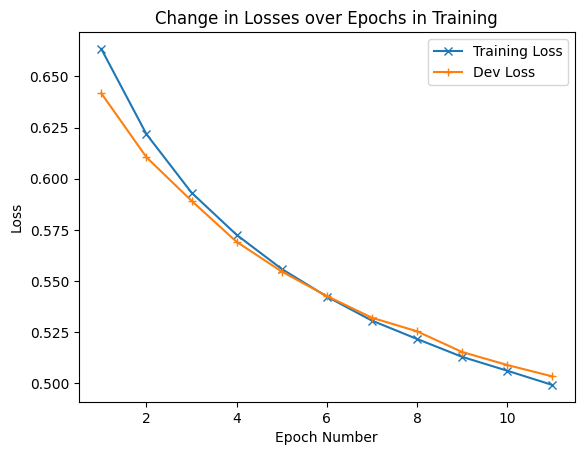


Accuracy: 77.46; Precision: 0.81; Recall: 0.72; F1 score: 0.76


In [ ]:
run_neural_model_pipeline(data, hparams)

## Submission Guidelines

Create a folder having your solution and should contain the following:
  - This notebook with your solution
  - All linked files provided in the 'Files to upload in notebook' folder
  - A 'solution/' folder containing the files mentioned below

Files to be generated and submitted:
Create a new folder called `submission/` and place the following files in it:
   - `test_preds_glove.txt` - Your best Glove model predictions for `word_analogy_test.txt`
   - `gdrive_link.txt` - Should contain a `wget`able to a folder that contains your best models. The model files should be named `glove.model`, and the folder should be named `538-hw1-<SBUID>-models`. Please make sure you provide the necessary permissions.
   - `<SBUID>_Report.pdf` - A PDF report as detailed below.


## Collaboration Guidelines

  - You can collaborate to discuss ideas and to help each other for better understanding of concepts and math.
  - You should NOT collaborate on the code level. This includes all implementation activities: design, coding, and debugging.
  - You should NOT not use any code that you did not write to complete the assignment.
  - The homework will be **cross-checked**. Do not cheat at all! It’s worth doing the homework partially instead of cheating and copying your code and get 0 for the whole homework. In previous years, students have faced harsh disciplinary action as a result of the same.


## Extra Notes

  - If you add any code apart from the TODOs in the codebase (note that you don't need to), please mark it by commenting in the code itself.
  An example of the same could be:
    ```
    # Adding some_global_var for XXX
    some_global_var
    ```
  - General tips when you work on tensor computations:
    - Break the whole list of operations into smaller ones.
    - Write down the shapes of the tensors


## Credits and Disclaimer

**Credits**: This code is part of the starter package of the assignment/s used in NLP course at Stony Brook University.
This assignment has been designed, implemented and revamped as required by many NLP TAs to varying degrees.
In chronological order of TAship they include Heeyoung Kwon, Jun Kang, Mohaddeseh Bastan, Harsh Trivedi, Matthew Matero, Nikita Soni, Sharvil Katariya, Yash Kumar Lal, Adithya V. Ganesan, Sounak Mondal, and Jasdeep Singh Grover. Thanks to all of them!

**Disclaimer/License**: This code is only for school assignment purpose, and **any version of this should NOT be shared publicly on github or otherwise even after semester ends**.
Public availability of answers devalues usability of the assignment and work of several TAs who have contributed to this.
We hope you'll respect this restriction.

In [ ]:
!wget -O "538-hw1-117411478-models.zip" "https://drive.google.com/file/d/1rcaeOIqjmw2cg4vxwZcvWhFoB1ccCnzg/view?usp=drive_link"

--2026-03-03 17:14:41--  https://drive.google.com/file/d/1rcaeOIqjmw2cg4vxwZcvWhFoB1ccCnzg/view?usp=drive_link
Resolving drive.google.com (drive.google.com)... 172.217.194.113, 172.217.194.138, 172.217.194.100, ...
Connecting to drive.google.com (drive.google.com)|172.217.194.113|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘538-hw1-117411478-models.zip’

538-hw1-117411478-m     [ <=>                ] 113.53K  --.-KB/s    in 0.04s   

2026-03-03 17:14:43 (2.56 MB/s) - ‘538-hw1-117411478-models.zip’ saved [116258]

